In [1]:
import numpy as np
import pandas as pd
from numpy.linalg import lstsq
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# ============================================================================
#  LOAD RAW OIS FILES  (explicit full paths via pd.read_excel)
# ============================================================================
# 3M / 6M / 9M / 1Y  -> Bloomberg format (a metadata block, then Date + PX_LAST)
# 2Y / 5Y / 10Y      -> OHLC format (Date repeated before Open/High/Low/Last Price)
OIS2Y      = pd.read_excel(r"C:\Users\Navya Subba\Downloads\OIS2Y.xlsx")
OIS5Y      = pd.read_excel(r"C:\Users\Navya Subba\Downloads\ois5y.xlsx")
OIS10Y     = pd.read_excel(r"C:\Users\Navya Subba\Downloads\OIS10Y.xlsx")
INR_OIS_6M = pd.read_excel(r"C:\Users\Navya Subba\Downloads\Porject 1\INR OIS 6M DAILY.xlsx")
INR_OIS_1Y = pd.read_excel(r"C:\Users\Navya Subba\Downloads\Porject 1\INR OIS 1Y DAILY (2).xlsx")
INR_OIS_3M = pd.read_excel(r"C:\Users\Navya Subba\Downloads\Porject 1\INR OIS 3M DAILY (1).xlsx")
INR_OIS_9M = pd.read_excel(r"C:\Users\Navya Subba\Downloads\Porject 1\INR OIS 9M DAILY (1).xlsx")

OUTPUT = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"


# ============================================================================
#  CLEANERS -- turn each raw frame into a single-column [Date -> level] series
# ============================================================================
def clean_bbg(raw, label):
    """
    Bloomberg xlsx already read via pd.read_excel: the real header sits a few
    rows down, so the top rows are metadata. Find the row whose cells contain
    'Date', re-key the columns off it, then keep Date + PX_LAST.
    """
    # Locate the header row (the one literally containing 'Date')
    header_row = None
    for i in range(len(raw)):
        if any(str(v).strip().lower() == "date" for v in raw.iloc[i].values):
            header_row = i
            break
    if header_row is not None:
        df = raw.iloc[header_row + 1:].copy()
        df.columns = [str(c).strip() for c in raw.iloc[header_row].values]
    else:
        # header was already the real header on read
        df = raw.copy()
        df.columns = [str(c).strip() for c in df.columns]

    df = df[["Date", "PX_LAST"]].copy()
    df.rename(columns={"PX_LAST": label}, inplace=True)

    df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    df[label]  = pd.to_numeric(df[label], errors="coerce")
    df.dropna(subset=["Date", label], inplace=True)

    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)
    df = df[~df.index.duplicated(keep="last")]
    return df


def clean_ohlc(raw, label):
    """
    OHLC xlsx read via pd.read_excel: columns come out as
    Date, Open Price, Date.1, High Price, Date.2, Low Price, Date.3, Last Price
    (pandas auto-mangles the repeated 'Date' headers). Take 'Last Price' as the
    daily level and pair it with the Date column immediately to its left.
    """
    df = raw.copy()
    df.columns = [str(c).strip() for c in df.columns]

    cols = list(df.columns)
    lp_idx   = next(i for i, c in enumerate(cols) if c.lower().startswith("last price"))
    date_idx = lp_idx - 1
    if not cols[date_idx].lower().startswith("date"):
        raise ValueError(
            f"[{label}] expected a 'Date' column immediately before 'Last Price', "
            f"got columns: {cols}"
        )

    out = df.iloc[:, [date_idx, lp_idx]].copy()
    out.columns = ["Date", label]

    out["Date"] = pd.to_datetime(out["Date"], dayfirst=True, errors="coerce")
    out[label]  = (
        out[label].astype(str)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )
    out.dropna(subset=["Date", label], inplace=True)

    out.set_index("Date", inplace=True)
    out.sort_index(inplace=True)
    out = out[~out.index.duplicated(keep="last")]
    return out


# ============================================================================
#  BUILD THE PER-TENOR SERIES  (order = 3M,6M,9M,1Y,2Y,5Y,10Y to match Section 4)
# ============================================================================
all_dfs = {
    "INR_OIS_3M":  clean_bbg(INR_OIS_3M,  "INR_OIS_3M"),
    "INR_OIS_6M":  clean_bbg(INR_OIS_6M,  "INR_OIS_6M"),
    "INR_OIS_9M":  clean_bbg(INR_OIS_9M,  "INR_OIS_9M"),
    "INR_OIS_1Y":  clean_bbg(INR_OIS_1Y,  "INR_OIS_1Y"),
    "INR_OIS_2Y":  clean_ohlc(OIS2Y,      "INR_OIS_2Y"),
    "INR_OIS_5Y":  clean_ohlc(OIS5Y,      "INR_OIS_5Y"),
    "INR_OIS_10Y": clean_ohlc(OIS10Y,     "INR_OIS_10Y"),
}

ois_labels = list(all_dfs.keys())

for lbl, df in all_dfs.items():
    print(f"  {lbl:18s}: {len(df):5d} rows | {df.index.min().date()} -> {df.index.max().date()}")


# ============================================================================
#  ALIGN INTO A MASTER CALENDAR  (common overlapping range only)
# ============================================================================
common_start = max(df.index.min() for df in all_dfs.values())
common_end   = min(df.index.max() for df in all_dfs.values())

print(f"\nCommon overlapping range across all series: {common_start.date()} -> {common_end.date()}")
if common_start > common_end:
    raise ValueError("No overlapping date range across all series -- cannot build a common master sheet.")

all_dates = sorted(set().union(*[df.index for df in all_dfs.values()]))
all_dates = [d for d in all_dates if common_start <= d <= common_end]

master = pd.DataFrame(index=pd.DatetimeIndex(all_dates))
master.index.name = "Date"

for lbl, df in all_dfs.items():
    master = master.join(df, how="left")

master.sort_index(inplace=True)

# Forward-fill gaps strictly between two real data points (safe: sheet is
# already clipped to the common range, so ffill can't run before/after either end).
master = master.ffill()

master.reset_index(inplace=True)

print(f"\nMaster table: {master.shape[0]} rows x {master.shape[1]} columns")
print(f"Date range  : {master['Date'].min().date()}  ->  {master['Date'].max().date()}")

print("\nForward-filled cell counts (within the common range):")
total_rows = len(master)
for lbl, df in all_dfs.items():
    actual_points_in_range = df.loc[common_start:common_end].shape[0]
    filled_count = total_rows - actual_points_in_range
    remaining_na = master[lbl].isna().sum()
    print(f"  {lbl:18s}: {filled_count:5d} filled / {total_rows} rows"
          f"  (actual data points in range: {actual_points_in_range}, remaining blanks: {remaining_na})")

date_values = master["Date"].tolist()
master["Date"] = master["Date"].dt.strftime("%d-%m-%Y")


# ============================================================================
#  WRITE FORMATTED MASTER EXCEL
# ============================================================================
HEADER_FILL = PatternFill("solid", start_color="1F4E79", end_color="1F4E79")
OIS_FILL_A  = PatternFill("solid", start_color="D6E4F0", end_color="D6E4F0")
OIS_FILL_B  = PatternFill("solid", start_color="C6D9F1", end_color="C6D9F1")
WHITE_FILL  = PatternFill("solid", start_color="FFFFFF", end_color="FFFFFF")
GREY_FILL   = PatternFill("solid", start_color="F2F2F2", end_color="F2F2F2")
thin        = Side(style="thin", color="BFBFBF")
border      = Border(left=thin, right=thin, top=thin, bottom=thin)

wb = Workbook()
ws = wb.active
ws.title = "Master Yields (Daily)"
cols = list(master.columns)

for col_idx, col_name in enumerate(cols, start=1):
    cell = ws.cell(row=1, column=col_idx, value=col_name.replace("_", " "))
    cell.font      = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill      = HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = border

for row_idx, row in master.iterrows():
    excel_row = row_idx + 2
    is_even   = row_idx % 2 == 0
    date_fill = WHITE_FILL if is_even else GREY_FILL
    for col_idx, col_name in enumerate(cols, start=1):
        val  = row[col_name]
        cell = ws.cell(row=excel_row, column=col_idx)
        if col_name == "Date":
            cell.value         = date_values[row_idx]
            cell.number_format = "DD-MM-YYYY"
            cell.alignment     = Alignment(horizontal="center")
            cell.fill          = date_fill
        elif pd.isna(val):
            cell.value = None
            cell.fill  = date_fill
        else:
            cell.value         = round(float(val), 4)
            cell.number_format = "0.0000"
            cell.alignment     = Alignment(horizontal="right")
            cell.fill          = OIS_FILL_A if is_even else OIS_FILL_B
        cell.font   = Font(name="Arial", size=9)
        cell.border = border

ws.column_dimensions["A"].width = 14
for col_idx in range(2, len(cols) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 16

ws.freeze_panes    = "A2"
ws.auto_filter.ref = ws.dimensions

wb.save(OUTPUT)
print(f"\nSaved: {OUTPUT}")

  INR_OIS_3M        :  5740 rows | 2003-01-01 -> 2026-03-30
  INR_OIS_6M        :  5734 rows | 2003-01-01 -> 2026-04-01
  INR_OIS_9M        :  5693 rows | 2003-01-01 -> 2026-03-31
  INR_OIS_1Y        :  5720 rows | 2003-01-01 -> 2026-02-27
  INR_OIS_2Y        :  5770 rows | 2003-01-01 -> 2026-03-31
  INR_OIS_5Y        :  5598 rows | 2003-08-13 -> 2026-03-31
  INR_OIS_10Y       :  5208 rows | 2004-11-09 -> 2026-03-30

Common overlapping range across all series: 2004-11-09 -> 2026-02-27

Master table: 5329 rows x 8 columns
Date range  : 2004-11-09  ->  2026-02-27

Forward-filled cell counts (within the common range):
  INR_OIS_3M        :    65 filled / 5329 rows  (actual data points in range: 5264, remaining blanks: 0)
  INR_OIS_6M        :    73 filled / 5329 rows  (actual data points in range: 5256, remaining blanks: 0)
  INR_OIS_9M        :   113 filled / 5329 rows  (actual data points in range: 5216, remaining blanks: 0)
  INR_OIS_1Y        :    67 filled / 5329 rows  (actual data p

In [3]:
master_path = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"
macro_path  = r"C:\Users\Navya Subba\Downloads\Porject 1\cleaned_data_monthly_ois (2).csv"


In [4]:

#import pandas as pd
import numpy as np
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# master_path should already be defined earlier in the notebook, e.g.:
# master_path = r"C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx"

# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 2 — LOAD & CLEAN DATA
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("  STEP 1: Loading and cleaning data")
print("=" * 60)

df = pd.read_excel(master_path)

print("Raw columns:", df.columns.tolist())
print("Raw shape  :", df.shape)

# Defensive cleanup: drop any stray/unnamed columns from a previous index
# round-trip, and de-duplicate any repeated column names.
df = df.loc[:, ~df.columns.astype(str).str.contains("Unnamed", case=False)]
df = df.loc[:, ~df.columns.duplicated()]

# Defensive cleanup: drop fully-blank rows that sometimes ride along at the
# bottom of an Excel sheet (these would otherwise survive as a row of NaNs).
df = df.dropna(how="all")

# Check for duplicate Date values — these silently corrupt set_index/resample
dup_dates = df["Date"].duplicated().sum()
if dup_dates:
    print(f"⚠ WARNING: {dup_dates} duplicate Date values found — keeping last occurrence")
    df = df.drop_duplicates(subset="Date", keep="last")

yield_cols = [c for c in df.columns if c != "Date"]
print(f"\nyield_cols ({len(yield_cols)}): {yield_cols}")

# Forward-fill weekends / holidays with last trading day value
df[yield_cols] = df[yield_cols].ffill()

# Drop rows where ANY column is still NaN
# (trims start date to when ALL series have data)
df = df.dropna(subset=yield_cols).reset_index(drop=True)

print(f"\nCleaned shape : {df.shape}")
print(f"Date range    : {df['Date'].iloc[0]}  →  {df['Date'].iloc[-1]}")
print(f"Remaining NaNs:\n{df[yield_cols].isna().sum()}")


# ── Write cleaned data back to Excel ─────────────────────────────────────────

HEADER_FILL = PatternFill("solid", start_color="1F4E79", end_color="1F4E79")
OIS_FILL_A  = PatternFill("solid", start_color="D6E4F0", end_color="D6E4F0")
OIS_FILL_B  = PatternFill("solid", start_color="C6D9F1", end_color="C6D9F1")
BOND_FILL_A = PatternFill("solid", start_color="E2EFDA", end_color="E2EFDA")
BOND_FILL_B = PatternFill("solid", start_color="D6E8C8", end_color="D6E8C8")
WHITE_FILL  = PatternFill("solid", start_color="FFFFFF", end_color="FFFFFF")
GREY_FILL   = PatternFill("solid", start_color="F2F2F2", end_color="F2F2F2")
thin        = Side(style="thin", color="BFBFBF")
border      = Border(left=thin, right=thin, top=thin, bottom=thin)

OIS_COLS  = [c for c in df.columns if "OIS"  in c]
BOND_COLS = [c for c in df.columns if "Bond" in c]

wb = Workbook()
ws = wb.active
ws.title = "Master Yields (Daily)"
cols = list(df.columns)

for col_idx, col_name in enumerate(cols, start=1):
    cell           = ws.cell(row=1, column=col_idx, value=col_name.replace("_", " "))
    cell.font      = Font(bold=True, color="FFFFFF", name="Arial", size=10)
    cell.fill      = HEADER_FILL
    cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    cell.border    = border

for row_idx, row in df.iterrows():
    excel_row = row_idx + 2
    is_even   = row_idx % 2 == 0
    for col_idx, col_name in enumerate(cols, start=1):
        val  = row[col_name]
        cell = ws.cell(row=excel_row, column=col_idx)
        if col_name == "Date":
            cell.value         = pd.Timestamp(val)
            cell.number_format = "DD-MM-YYYY"
            cell.alignment     = Alignment(horizontal="center")
            cell.fill          = WHITE_FILL if is_even else GREY_FILL
        elif pd.isna(val):
            cell.value = None
            cell.fill  = WHITE_FILL if is_even else GREY_FILL
        else:
            cell.value         = round(float(val), 4)
            cell.number_format = "0.0000"
            cell.alignment     = Alignment(horizontal="right")
            if col_name in OIS_COLS:
                cell.fill = OIS_FILL_A if is_even else OIS_FILL_B
            elif col_name in BOND_COLS:
                cell.fill = BOND_FILL_A if is_even else BOND_FILL_B
            else:
                cell.fill = WHITE_FILL if is_even else GREY_FILL
        cell.font   = Font(name="Arial", size=9)
        cell.border = border

ws.column_dimensions["A"].width = 14
for col_idx in range(2, len(cols) + 1):
    ws.column_dimensions[get_column_letter(col_idx)].width = 16

ws.freeze_panes    = "A2"
ws.auto_filter.ref = ws.dimensions
wb.save(master_path)
print(f"\n✅  Excel saved: {master_path}")




  STEP 1: Loading and cleaning data
Raw columns: ['Date', 'INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']
Raw shape  : (5329, 8)

yield_cols (7): ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']

Cleaned shape : (5329, 8)
Date range    : 2004-11-09 00:00:00  →  2026-02-27 00:00:00
Remaining NaNs:
INR OIS 3M     0
INR OIS 6M     0
INR OIS 9M     0
INR OIS 1Y     0
INR OIS 2Y     0
INR OIS 5Y     0
INR OIS 10Y    0
dtype: int64

✅  Excel saved: C:\Users\Navya Subba\Downloads\Porject 1\Master_Yields_Daily_yieldsonly.xlsx


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 3 — TRAIN / TEST SPLIT
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 2: Train / Test split")
print("=" * 60)

df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.set_index("Date")

print("After set_index, columns:", df.columns.tolist())
assert "Date" not in df.columns, "Date is still a column after set_index — investigate!"

# Split: train ≤ 2022-12-31, test > 2022-12-31
train_df = df[df.index <= "2022-12-31"]
test_df  = df[df.index >  "2022-12-31"]

print(f"Train (daily): {train_df.index[0].date()}  →  {train_df.index[-1].date()}  "
      f"({len(train_df)} rows)")
print(f"Test  (daily): {test_df.index[0].date()}   →  {test_df.index[-1].date()}   "
      f"({len(test_df)} rows)")

# Resample to monthly (last trading day of each month)
yields_train = train_df.resample("MS").last()
yields_test  = test_df.resample("MS").last()

print(f"\nMonthly train : {len(yields_train)} months, columns: {yields_train.columns.tolist()}")
print(f"Monthly test  : {len(yields_test)}  months, columns: {yields_test.columns.tolist()}")





  STEP 2: Train / Test split
After set_index, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']
Train (daily): 2004-11-09  →  2022-12-30  (4540 rows)
Test  (daily): 2023-01-02   →  2026-02-27   (789 rows)

Monthly train : 218 months, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']
Monthly test  : 38  months, columns: ['INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 4 — NELSON-SIEGEL FUNCTIONS
#
#  Model:  y_t(n) = L_t + S_t·B1(n) + C_t·B2(n) + ε_t(n)
#  Fixed decay parameter λ = 0.0609 (Diebold-Li 2006)
# ══════════════════════════════════════════════════════════════════════════════

LAMBDA     = 0.0609
maturities = [0.25, 0.50, 0.75, 1.00, 2.00, 5.00, 10.00]   # years: 3M, 6M, 9M, 1Y, 2Y, 5Y, 10Y

# Guard-rail: maturities must line up 1:1 with the yield columns, in order.
assert len(maturities) == len(yield_cols), (
    f"maturities has {len(maturities)} entries but yield_cols has "
    f"{len(yield_cols)} entries ({yield_cols}). They must match exactly, "
    f"in the same order, before extract_factors is called."
)


def ns_loadings(maturities, lam=LAMBDA):
    """(M × 3) NS loading matrix: columns [1 (Level), B1 (Slope), B2 (Curvature)]."""
    n  = np.asarray(maturities, dtype=float)
    ln = lam * n
    B1 = (1 - np.exp(-ln)) / ln          # monotone decay, 1 → 0
    B2 = B1 - np.exp(-ln)                # hump shape,     0 → peak → 0
    return np.column_stack([np.ones_like(n), B1, B2])


def extract_factors(yields_df, maturities, lam=LAMBDA, ridge_alpha=1e-3):
    """
    Per-date cross-sectional ridge OLS:  y_t = X · [L_t, S_t, C_t]' + ε_t.
    Returns DataFrame with columns L, S, C, R2 indexed by date.
    """
    from sklearn.linear_model import Ridge

    mats = np.asarray(maturities, dtype=float)
    X    = ns_loadings(mats, lam)            # (M, 3) — computed once

    # Hard guard-rail: catch a column/maturity mismatch immediately, with a
    # clear message, instead of letting it surface later as a cryptic
    # boolean-mask IndexError inside the loop below.
    n_cols = yields_df.shape[1]
    if X.shape[0] != n_cols:
        raise ValueError(
            f"Shape mismatch: yields_df has {n_cols} columns "
            f"{list(yields_df.columns)}, but maturities has {X.shape[0]} "
            f"entries {list(maturities)}. Fix maturities or yields_df "
            f"before calling extract_factors."
        )

    records = []

    for date, row in yields_df.iterrows():
        y    = row.values.astype(float)
        mask = ~np.isnan(y)
        if mask.sum() < 3:
            records.append({"Date": date, "L": np.nan, "S": np.nan,
                            "C": np.nan, "R2": np.nan})
            continue

        y_obs = y[mask]
        X_obs = X[mask]

        ridge = Ridge(alpha=ridge_alpha, fit_intercept=False)
        ridge.fit(X_obs, y_obs)
        L_t, S_t, C_t = ridge.coef_

        y_hat  = X_obs @ ridge.coef_
        ss_res = np.sum((y_obs - y_hat) ** 2)
        ss_tot = np.sum((y_obs - y_obs.mean()) ** 2)
        r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        records.append({"Date": date, "L": L_t, "S": S_t, "C": C_t, "R2": r2})

    return pd.DataFrame(records).set_index("Date")


def fitted_yields(factors_df, maturities, lam=LAMBDA):
    """Reconstruct fitted curve ŷ_t(n) = L + S·B1 + C·B2. Returns (T × M)."""
    X      = ns_loadings(np.asarray(maturities, dtype=float), lam)
    LSC    = factors_df[["L", "S", "C"]].values
    fitted = LSC @ X.T
    return pd.DataFrame(fitted, index=factors_df.index,
                        columns=np.asarray(maturities, dtype=float))


def summarise_factors(factors_df, label=""):
    print("\n" + "=" * 55)
    print(f"  Nelson-Siegel Factor Summary  {label}")
    print("=" * 55)
    print(factors_df[["L", "S", "C"]].describe().round(4).to_string())
    print(f"\n  Mean in-sample R²  : {factors_df['R2'].mean():.6f}")
    print(f"  Min  in-sample R²  : {factors_df['R2'].min():.6f}")
    print("=" * 55 + "\n")




In [7]:
df = pd.read_excel(master_path)
print(df.columns.tolist())
print(df.shape)

['Date', 'INR OIS 3M', 'INR OIS 6M', 'INR OIS 9M', 'INR OIS 1Y', 'INR OIS 2Y', 'INR OIS 5Y', 'INR OIS 10Y']
(5329, 8)


Loading G-sec benchmark yields & computing spreads...
  Spread series built: 4535 rows | 2008-01-02 -> 2026-02-27

  Spread summary (basis points):
            mean   std    min    max
Spread_2Y   43.5  27.7 -104.4  158.7
Spread_5Y   62.1  33.0 -145.5  163.3
Spread_10Y  59.6  40.7 -181.0  195.0


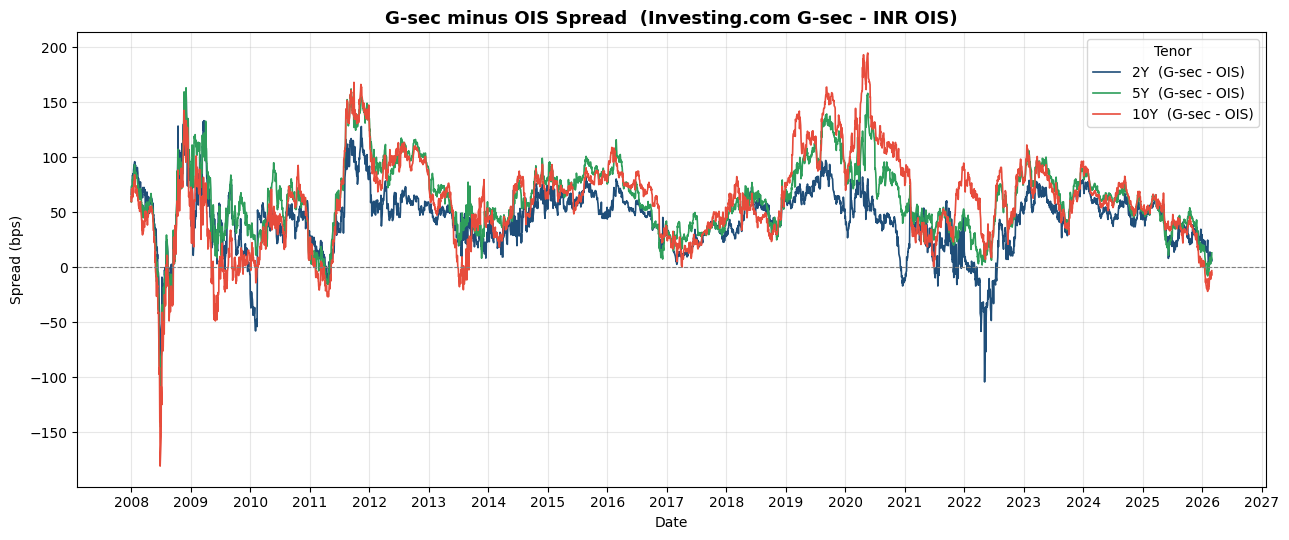

In [8]:
# ==============================================================================
#  SECTION 2b -- G-SEC minus OIS SPREAD  (2Y / 5Y / 10Y)
# ==============================================================================
# The OIS curve is a clean expectations measure (no funding/credit/supply leg).
# The G-sec curve carries those extra premia. Their difference is where term
# premium, G-sec supply, and liquidity effects show up. We compute it at the
# three tenors where liquid G-sec benchmarks line up with our OIS tenors.
#
# Spread(t) = G-sec yield(t) - OIS(t),   quoted in basis points (x100).

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -- G-sec benchmark yield files (Investing.com daily CSV) --------------------
GSEC_FILES = {
    "2Y":  r"C:\Users\Navya Subba\Downloads\Porject 1\India 2-Year Bond Yield Historical Data.csv",
    "5Y":  r"C:\Users\Navya Subba\Downloads\Porject 1\India 5-Year Bond Yield Historical Data.csv",
    "10Y": r"C:\Users\Navya Subba\Downloads\Porject 1\India 10-Year Bond Yield Historical Data (1).csv",
}


def load_gsec(path, label):
    """Investing.com CSV: keep Date + Price (the yield). Handles %/comma + mixed date formats."""
    g = pd.read_csv(path)
    g.columns = g.columns.str.strip()

    date_col  = next(c for c in g.columns if c.lower() == "date")
    price_col = next(c for c in g.columns if c.lower() == "price")

    g = g[[date_col, price_col]].copy()
    g.rename(columns={date_col: "Date", price_col: label}, inplace=True)

    g[label] = (
        g[label].astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

    for fmt in ("%d-%m-%Y", "%b %d, %Y", "%Y-%m-%d", "%m/%d/%Y"):
        try:
            g["Date"] = pd.to_datetime(g["Date"], format=fmt, errors="raise")
            break
        except Exception:
            continue
    else:
        g["Date"] = pd.to_datetime(g["Date"], dayfirst=True, errors="coerce")

    g.dropna(subset=["Date", label], inplace=True)
    g.set_index("Date", inplace=True)
    g.sort_index(inplace=True)
    g = g[~g.index.duplicated(keep="last")]
    return g[label]


# -- OIS side: pull the matching tenors out of the daily master `df` -----------
# `df` was loaded from master_path a few cells up and is OIS-only.
ois_daily = df.copy()
ois_daily["Date"] = pd.to_datetime(ois_daily["Date"])
ois_daily = ois_daily.set_index("Date").sort_index()

# -- Build the spread frame ----------------------------------------------------
print("Loading G-sec benchmark yields & computing spreads...")
spread = pd.DataFrame(index=ois_daily.index)
gsec_levels = pd.DataFrame(index=ois_daily.index)

for tenor in ("2Y", "5Y", "10Y"):
    gsec = load_gsec(GSEC_FILES[tenor], f"GSEC_{tenor}")
    ois_col = f"INR OIS {tenor}"

    # Align G-sec onto the OIS calendar; ffill only bridges gaps between real points
    gsec_aligned = gsec.reindex(ois_daily.index).ffill()

    gsec_levels[f"GSEC_{tenor}"] = gsec_aligned
    spread[f"Spread_{tenor}"] = (gsec_aligned - ois_daily[ois_col]) * 100.0  # -> bps

# Restrict to the range where BOTH legs actually have data (drop leading NaNs)
spread = spread.dropna(how="any")
gsec_levels = gsec_levels.loc[spread.index]

print(f"  Spread series built: {spread.shape[0]} rows | "
      f"{spread.index.min().date()} -> {spread.index.max().date()}")
print("\n  Spread summary (basis points):")
print(spread.describe().round(1).T[["mean", "std", "min", "max"]])

# -- Plot: the three spreads over time -----------------------------------------
COLORS = {"2Y": "#1F4E79", "5Y": "#2E9E5B", "10Y": "#E74C3C"}

fig, ax = plt.subplots(figsize=(13, 5.5))
for tenor in ("2Y", "5Y", "10Y"):
    ax.plot(spread.index, spread[f"Spread_{tenor}"],
            color=COLORS[tenor], linewidth=1.2, label=f"{tenor}  (G-sec - OIS)")

ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("G-sec minus OIS Spread  (Investing.com G-sec - INR OIS)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Spread (bps)")
ax.legend(title="Tenor", loc="best")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

# Keep `spread` and `gsec_levels` around for any later modelling of the spread.

In [9]:
## ══════════════════════════════════════════════════════════════════════════════
#  SECTION 5 — EXTRACT NS FACTORS  (TRAIN ONLY)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 3: Extracting Nelson-Siegel factors (train only)")
print("=" * 60)

factors_train = extract_factors(yields_train, maturities)
summarise_factors(factors_train, label="— TRAIN (2008 – 2022)")
print("factors_train (first 5 rows):")
print(factors_train.head().round(4))


  STEP 3: Extracting Nelson-Siegel factors (train only)

  Nelson-Siegel Factor Summary  — TRAIN (2008 – 2022)
              L         S         C
count  218.0000  218.0000  218.0000
mean     5.4601    0.8644    3.8989
std      0.7442    1.4257    4.3864
min      3.6730   -3.2876   -6.1956
25%      4.8131    0.0454    1.1640
50%      5.5789    1.2766    3.1605
75%      6.0001    1.9009    6.0031
max      7.3626    3.6034   16.2594

  Mean in-sample R²  : 0.661014
  Min  in-sample R²  : -0.171859

factors_train (first 5 rows):
                 L       S       C      R2
Date                                      
2004-11-01  6.3093 -1.0359  7.0879  0.9806
2004-12-01  5.7475 -0.4349  6.1976  0.9765
2005-01-01  5.8799 -0.6440  7.1383  0.9828
2005-02-01  5.5196 -0.2930  6.9725  0.9736
2005-03-01  5.7611 -0.5474  7.9238  0.9710



  STEP 4: Generating plots


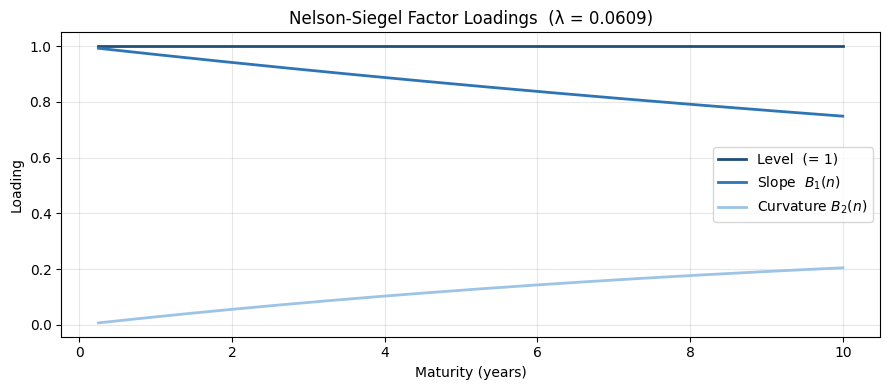

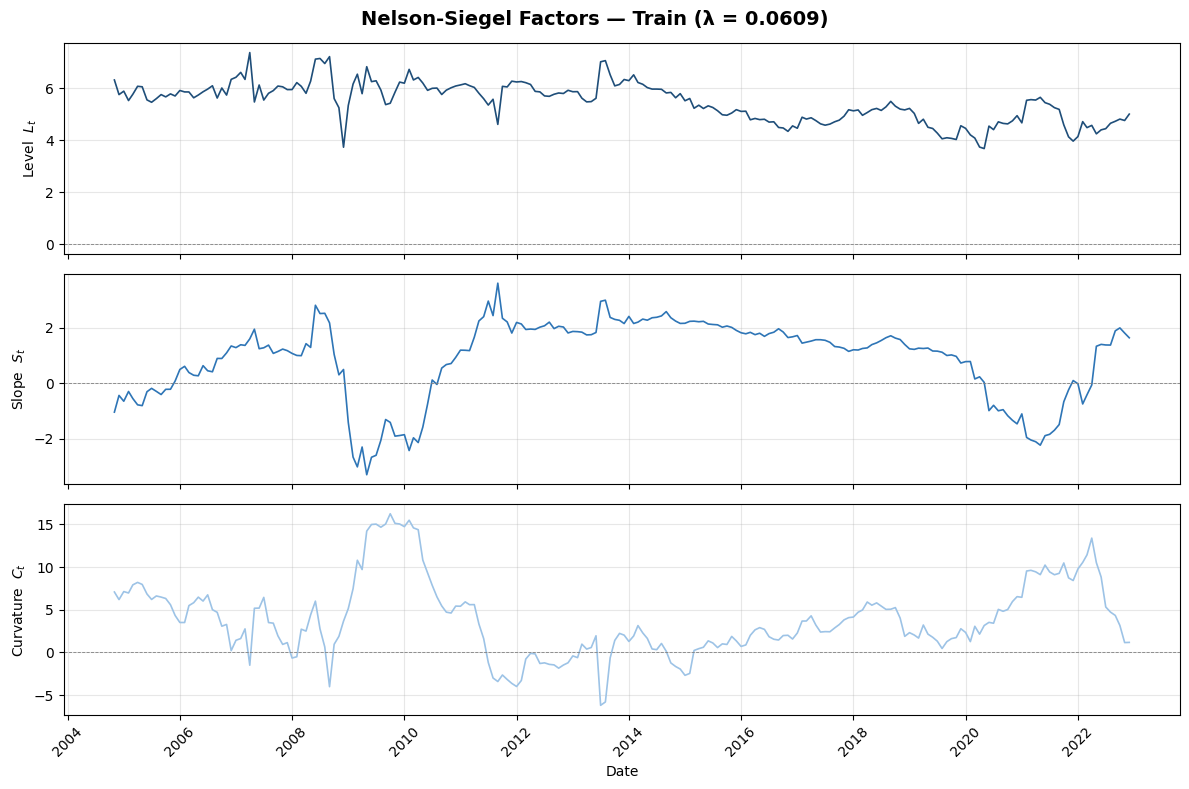

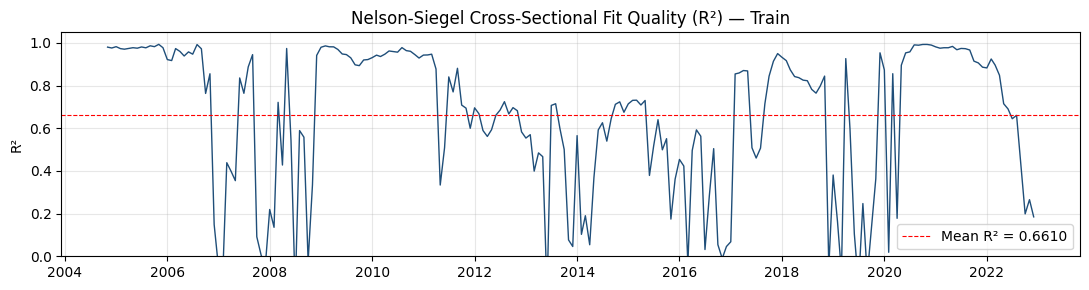

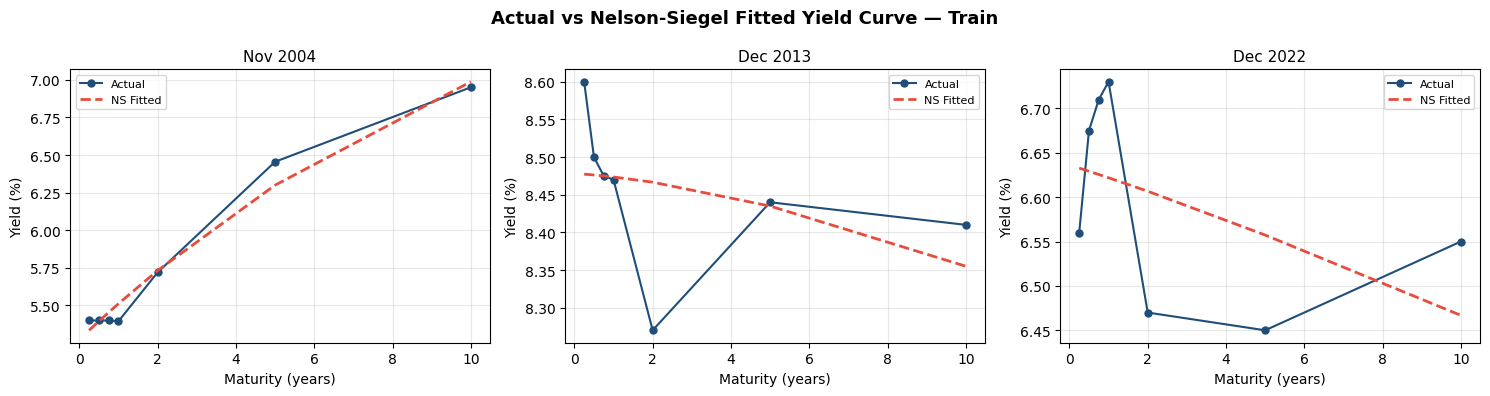


✅  factors_train ready for VAR estimation.
    Shape: (218, 4)  Columns: ['L', 'S', 'C', 'R2']


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 6 — PLOTS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 4: Generating plots")
print("=" * 60)

mats_fine = np.linspace(min(maturities), max(maturities), 300)
X_fine    = ns_loadings(mats_fine)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mats_fine, X_fine[:, 0], label="Level  (= 1)",       color="#1F4E79", linewidth=2)
ax.plot(mats_fine, X_fine[:, 1], label="Slope  $B_1(n)$",    color="#2E75B6", linewidth=2)
ax.plot(mats_fine, X_fine[:, 2], label="Curvature $B_2(n)$", color="#9DC3E6", linewidth=2)
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Loading")
ax.set_title(f"Nelson-Siegel Factor Loadings  (λ = {LAMBDA})")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Nelson-Siegel Factors — Train (λ = 0.0609)", fontsize=14, fontweight="bold")
colors = {"L": "#1F4E79", "S": "#2E75B6", "C": "#9DC3E6"}
labels = {"L": "Level  $L_t$", "S": "Slope  $S_t$", "C": "Curvature  $C_t$"}
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(factors_train.index, factors_train[col], color=colors[col], linewidth=1.2)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(labels[col], fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(factors_train.index, factors_train["R2"], color="#1F4E79", linewidth=1.0)
ax.axhline(factors_train["R2"].mean(), color="red", linestyle="--",
           linewidth=0.8, label=f"Mean R² = {factors_train['R2'].mean():.4f}")
ax.set_ylabel("R²"); ax.set_title("Nelson-Siegel Cross-Sectional Fit Quality (R²) — Train")
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fitted_train = fitted_yields(factors_train, maturities)
mats         = np.asarray(maturities, dtype=float)
sample_dates = [yields_train.index[0],
                yields_train.index[len(yields_train) // 2],
                yields_train.index[-1]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, date in zip(axes, sample_dates):
    ax.plot(mats, yields_train.loc[date].values, "o-", color="#1F4E79",
            linewidth=1.5, markersize=5, label="Actual")
    ax.plot(mats, fitted_train.loc[date].values, "--", color="#E74C3C",
            linewidth=2, label="NS Fitted")
    ax.set_title(pd.Timestamp(date).strftime("%b %Y"), fontsize=11)
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.suptitle("Actual vs Nelson-Siegel Fitted Yield Curve — Train",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n✅  factors_train ready for VAR estimation.")
print(f"    Shape: {factors_train.shape}  Columns: {list(factors_train.columns)}")




  STEP 5: DNS VAR estimation on factors_train (BIC lag)

Lag order selection (AIC / BIC / FPE / HQIC):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       1.968       2.016       7.158       1.987
1      -3.655     -3.465*     0.02586     -3.578*
2     -3.711*      -3.379    0.02445*      -3.577
3      -3.659      -3.184     0.02575      -3.467
4      -3.697      -3.079     0.02481      -3.447
5      -3.687      -2.927     0.02506      -3.380
6      -3.660      -2.757     0.02577      -3.295
-------------------------------------------------

  AIC selects lag = 2   (kept as DNS-AIC benchmark)
  BIC selects lag = 1   ← MAIN model for forecasting

════════════════════════════════════════════════════════════
  MAIN MODEL — DNS VAR(1)  [BIC]
════════════════════════════════════════════════════════════
  Summary of Regression Results   
Model:                         VAR
Method:       

C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


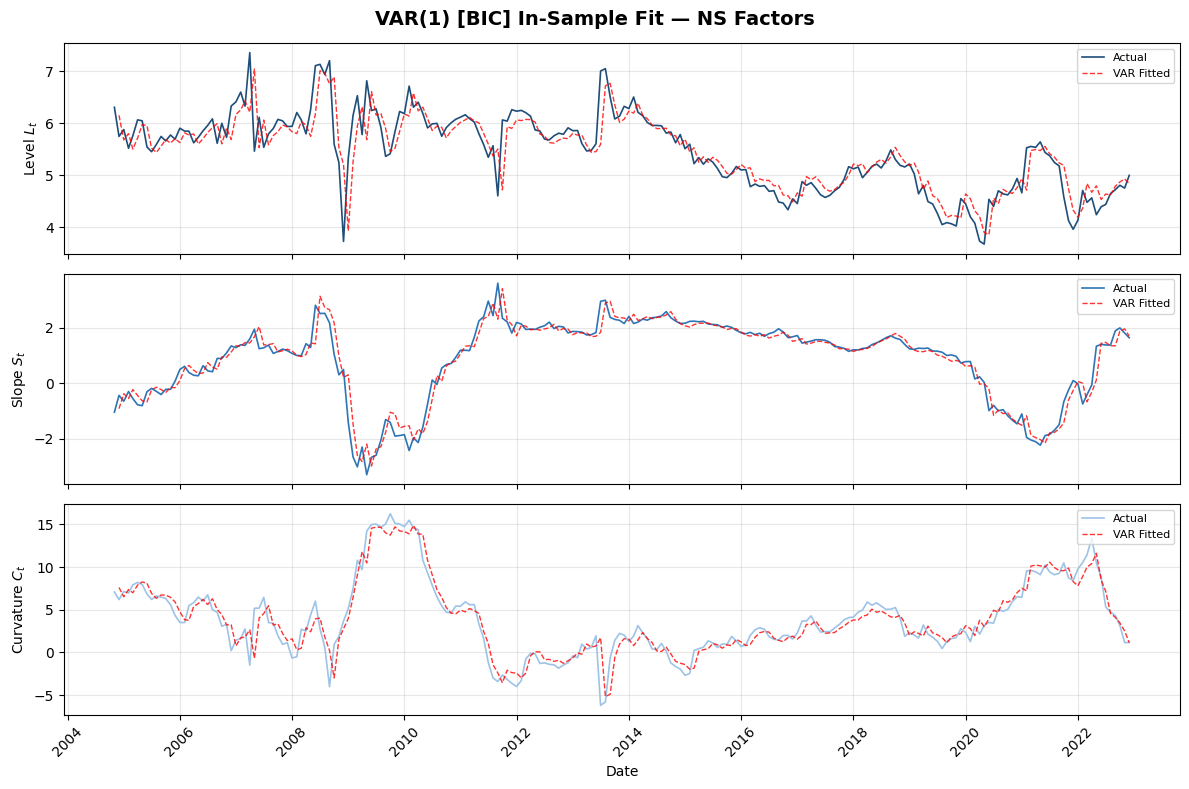

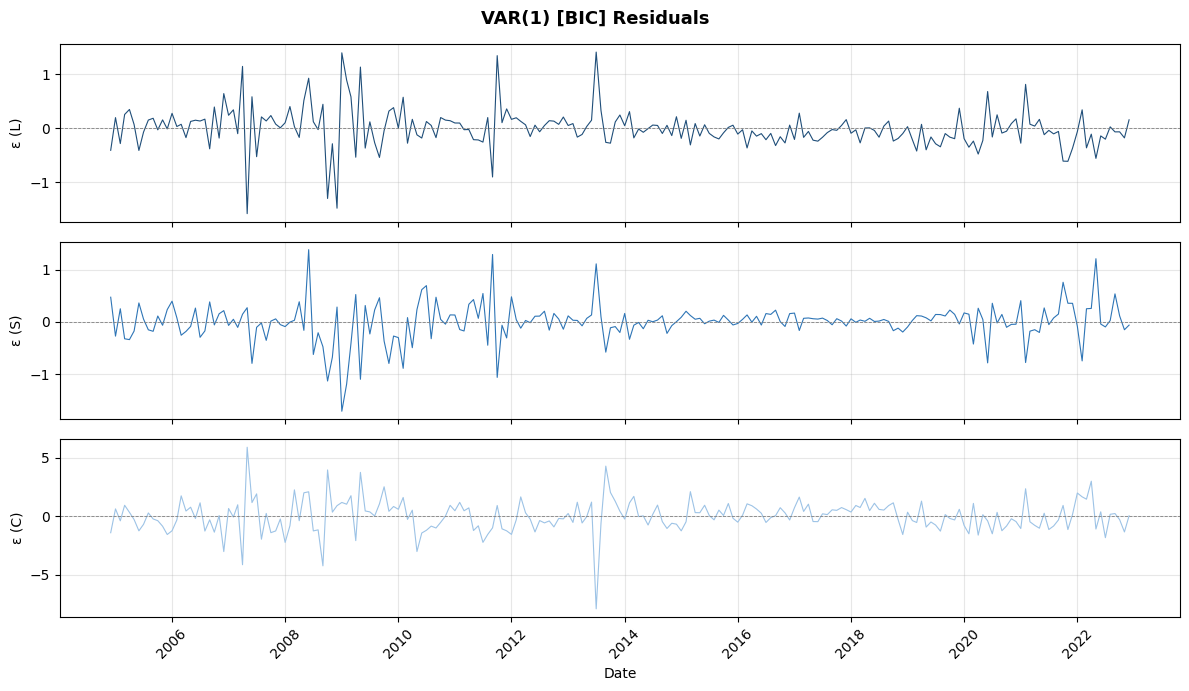

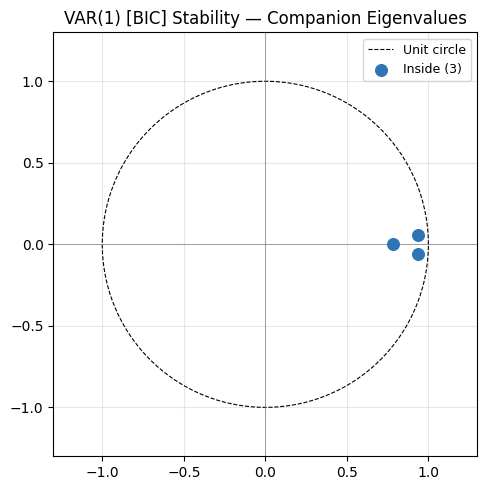


✅  DNS VAR done. var_result (BIC p=1), var_result_aic (AIC p=2).


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 7 — DNS VAR ESTIMATION  (BIC lag main; AIC kept as benchmark)
#
#      X_t = μ + A1·X_{t-1} + ... + Ap·X_{t-p} + ε_t,   X_t = [L,S,C]'
#
#  Stability: all eigenvalues of the FULL COMPANION MATRIX (K·p × K·p) must lie
#  inside the unit circle (checking only A1 is wrong for p > 1).
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.api import VAR

print("\n" + "=" * 60)
print("  STEP 5: DNS VAR estimation on factors_train (BIC lag)")
print("=" * 60)

var_data   = factors_train[["L", "S", "C"]].dropna()

# Lag selection on its own throwaway instance
lag_result = VAR(var_data).select_order(maxlags=6)
print("\nLag order selection (AIC / BIC / FPE / HQIC):")
print(lag_result.summary())

best_lag_aic = max(lag_result.aic, 1)   # AIC lag (benchmark)
best_lag     = max(lag_result.bic, 1)   # BIC lag (MAIN — floor at 1)
print(f"\n  AIC selects lag = {best_lag_aic}   (kept as DNS-AIC benchmark)")
print(f"  BIC selects lag = {best_lag}   ← MAIN model for forecasting")

# FIX: fit each lag on a FRESH VAR(...) instance so the two results never share
# mutable column-name metadata (that sharing caused the (4,3) vs (13,3) error).
var_result     = VAR(var_data).fit(maxlags=best_lag,     ic=None)   # BIC (main)
var_result_aic = VAR(var_data).fit(maxlags=best_lag_aic, ic=None)   # AIC (benchmark)

print("\n" + "═" * 60)
print(f"  MAIN MODEL — DNS VAR({best_lag})  [BIC]")
print("═" * 60)
print(var_result.summary())

# Robust intercept extraction (works regardless of params wrapping quirks)
mu = np.asarray(var_result.params.loc["const"]).ravel()
print("\nIntercept vector μ:")
print(pd.Series(mu, index=["L", "S", "C"]).round(6).to_string())

A = var_result.coefs[0]   # lag-1 matrix (descriptive only)
print(f"\nLag-1 coefficient matrix A1 (descriptive, VAR lag={best_lag}):")
print(pd.DataFrame(A, index=["L eq", "S eq", "C eq"],
                   columns=["L(-1)", "S(-1)", "C(-1)"]).round(4).to_string())

sigma = var_result.sigma_u
print("\nResidual covariance matrix Σ:")
print(pd.DataFrame(sigma, index=["L", "S", "C"],
                   columns=["L", "S", "C"]).round(6).to_string())


# ── Stability helpers (full companion matrix) ────────────────────────────────
def companion_matrix(var_res):
    """Full (K·p × K·p) companion matrix from a fitted VARResults."""
    coefs = var_res.coefs                       # (p, K, K)
    p, K, _ = coefs.shape
    F = np.zeros((K * p, K * p))
    F[:K, :] = np.hstack([coefs[i] for i in range(p)])
    if p > 1:
        F[K:, :-K] = np.eye(K * (p - 1))
    return F


def stability_report(var_res, label="VAR"):
    """Eigenvalues of companion matrix + verdict, cross-checked vs statsmodels."""
    F      = companion_matrix(var_res)
    eigs   = np.linalg.eigvals(F)
    order  = np.argsort(-np.abs(eigs))
    eigs   = eigs[order]
    moduli = np.abs(eigs)
    stable = bool(np.all(moduli < 1.0))

    p, K = var_res.k_ar, var_res.neqs
    print("\n" + "─" * 62)
    print(f"Stability Check — {label}   (K = {K} variables, p = {p} lags)")
    print(f"Companion matrix: {K*p}×{K*p}  →  {K*p} eigenvalues")
    print("─" * 62)
    for i, (ev, mod) in enumerate(zip(eigs, moduli)):
        flag = "✅ inside unit circle" if mod < 1 else "❌ OUTSIDE unit circle"
        print(f"  λ{i+1:2d} = {ev.real:+.6f}{ev.imag:+.6f}j   |λ| = {mod:.6f}  {flag}")
    print(f"\n  Largest |λ| = {moduli[0]:.6f}")
    if stable and moduli[0] > 0.97:
        print("  ⚠️  Near-unit root: stable but highly persistent (normal for the")
        print("      level factor; long-horizon forecasts mean-revert slowly).")
    print(f"\n  {label} is {'STABLE ✅' if stable else 'UNSTABLE ❌'}")
    sm_stable = var_res.is_stable()
    print(f"  Cross-check: statsmodels is_stable() = {sm_stable}  "
          f"{'✅' if sm_stable == stable else '❌ MISMATCH!'}")
    print("─" * 62)
    assert np.allclose(np.sort(moduli), np.sort(1.0 / np.abs(var_res.roots))), \
        "Companion eigenvalues don't match 1/|statsmodels roots|"
    return eigs, moduli, stable


eigenvalues, moduli, is_stable = stability_report(var_result, label=f"DNS VAR({best_lag}) [BIC]")
eigenvalues_aic, moduli_aic, is_stable_aic = stability_report(
    var_result_aic, label=f"DNS VAR({best_lag_aic}) [AIC]")

print("\n  AIC vs BIC model structure (DNS):")
print(pd.DataFrame({
    f"BIC (p={best_lag})": {
        "total params": var_result.params.size, "obs used": var_result.nobs,
        "max |λ|": round(moduli[0], 4), "stable": is_stable},
    f"AIC (p={best_lag_aic})": {
        "total params": var_result_aic.params.size, "obs used": var_result_aic.nobs,
        "max |λ|": round(moduli_aic[0], 4), "stable": is_stable_aic},
}).to_string())

# ── Fit / residual / stability plots (BIC model) ─────────────────────────────
factor_colors = {"L": "#1F4E79", "S": "#2E75B6", "C": "#9DC3E6"}
factor_labels = {"L": "Level $L_t$", "S": "Slope $S_t$", "C": "Curvature $C_t$"}

var_fitted = var_result.fittedvalues
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"VAR({best_lag}) [BIC] In-Sample Fit — NS Factors", fontsize=14, fontweight="bold")
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(var_data.index, var_data[col], color=factor_colors[col], linewidth=1.2, label="Actual")
    ax.plot(var_fitted.index, var_fitted[col], color="red", linewidth=1.0,
            linestyle="--", label="VAR Fitted", alpha=0.8)
    ax.set_ylabel(factor_labels[col], fontsize=10); ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

var_resid = var_result.resid
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig.suptitle(f"VAR({best_lag}) [BIC] Residuals", fontsize=13, fontweight="bold")
for ax, col in zip(axes, ["L", "S", "C"]):
    ax.plot(var_resid.index, var_resid[col], color=factor_colors[col], linewidth=0.8)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(f"ε ({col})", fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8, label="Unit circle")
inside = moduli < 1
ax.scatter(eigenvalues[inside].real, eigenvalues[inside].imag, color="#2E75B6",
           zorder=5, s=70, label=f"Inside ({inside.sum()})")
if (~inside).any():
    ax.scatter(eigenvalues[~inside].real, eigenvalues[~inside].imag, color="#E74C3C",
               zorder=6, s=90, marker="X", label=f"OUTSIDE ({(~inside).sum()})")
lim = max(1.3, moduli.max() * 1.15)
ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_title(f"VAR({best_lag}) [BIC] Stability — Companion Eigenvalues")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\n✅  DNS VAR done. var_result (BIC p={best_lag}), "
      f"var_result_aic (AIC p={best_lag_aic}).")


  STEP 6: Loading macro data & PCA
  Date parsed with format: %Y-%m-%d

  Macro raw shape   : (248, 49)
  Macro date range  : 2005-01-31  →  2025-08-31
  Macro columns     : ['FOREX', 'CAPITAL_ACCOUNT', 'NET_BANK_RESERVES', 'CREDIT_TO_GOV', 'LOANS_ADVANCES_FROM_RBI', 'DOMESTIC_CREDIT', 'LONG_TERM_TIME_DEPOSIT', 'WPI_INFLATION', 'REPO_RATE', 'IN10Y', 'EURINR', 'GBPINR', 'GOLD', 'IN01Y', 'IN03MY', 'IN05Y', 'IN06MY', 'ININBR', 'NIFTY', 'SPX', 'UKOIL', 'US10Y', 'USDINR', 'VIX', '1Y', '2Y', '3M', '6M', '9M', 'spread_3M_6M', 'spread_3M_9M', 'spread_3M_1Y', 'spread_3M_2Y', 'spread_6M_9M', 'spread_6M_1Y', 'spread_6M_2Y', 'spread_9M_1Y', 'spread_9M_2Y', 'spread_1Y_2Y', 'fwd_3M_6M', 'fwd_3M_9M', 'fwd_3M_1Y', 'fwd_3M_2Y', 'fwd_6M_9M', 'fwd_6M_1Y', 'fwd_6M_2Y', 'fwd_9M_1Y', 'fwd_9M_2Y', 'fwd_1Y_2Y']

  After date snap   : 2005-01-01  →  2025-08-01

  Macro train shape : (216, 49)
  Macro after cleaning: (216, 49)

  ADF Test & Stationarity Transformations:
  Variable                              

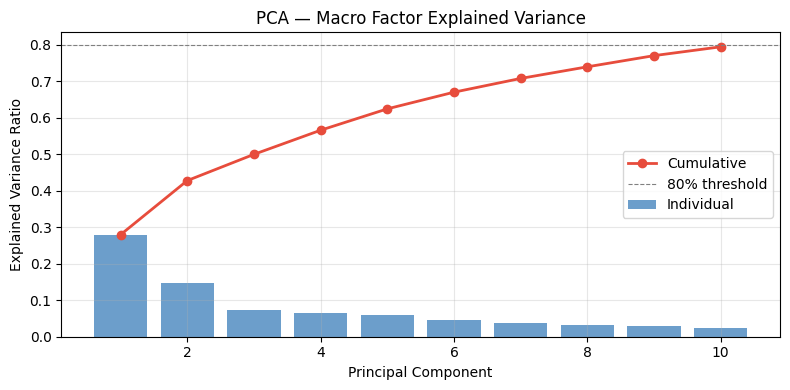

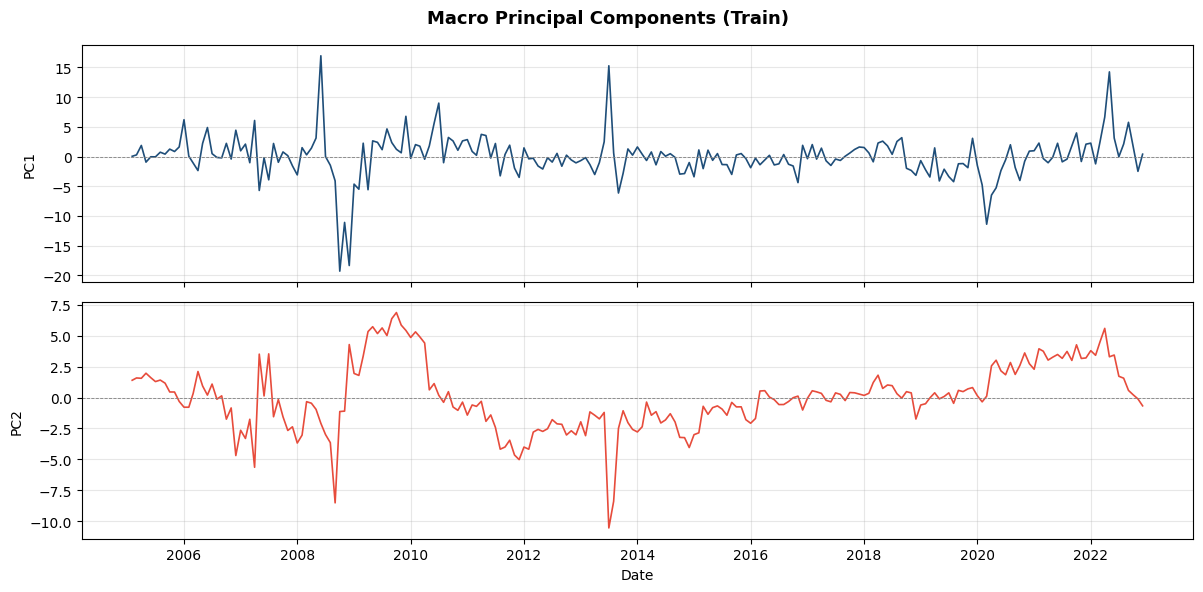

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 8 — MACRO FACTOR EXTRACTION (PCA)
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller

print("\n" + "=" * 60)
print("  STEP 6: Loading macro data & PCA")
print("=" * 60)

macro_raw = pd.read_csv(macro_path)
macro_raw.columns = macro_raw.columns.str.strip()
date_col = next(c for c in macro_raw.columns if c.lower() == "date")

for fmt in ("%d-%m-%Y", "%Y-%m-%d", "%m/%d/%Y", "%b %d, %Y"):
    try:
        macro_raw[date_col] = pd.to_datetime(macro_raw[date_col], format=fmt, errors="raise")
        print(f"  Date parsed with format: {fmt}")
        break
    except Exception:
        continue
else:
    macro_raw[date_col] = pd.to_datetime(macro_raw[date_col], dayfirst=True, errors="coerce")
    print("  Date parsed with dayfirst=True")

macro_raw = macro_raw.rename(columns={date_col: "Date"}).set_index("Date").sort_index()
macro_raw = macro_raw.apply(pd.to_numeric, errors="coerce")
print(f"\n  Macro raw shape   : {macro_raw.shape}")
print(f"  Macro date range  : {macro_raw.index[0].date()}  →  {macro_raw.index[-1].date()}")
print(f"  Macro columns     : {list(macro_raw.columns)}")

# Snap to month-start to match yields_train index
macro_raw.index = macro_raw.index.to_period("M").to_timestamp("s")
print(f"\n  After date snap   : {macro_raw.index[0].date()}  →  {macro_raw.index[-1].date()}")

train_start, train_end = yields_train.index[0], yields_train.index[-1]
macro_train = macro_raw.loc[(macro_raw.index >= train_start) &
                            (macro_raw.index <= train_end)].copy()
print(f"\n  Macro train shape : {macro_train.shape}")

nan_pct = macro_train.isna().mean()
drop_cols = nan_pct[nan_pct > 0.2].index.tolist()
if drop_cols:
    print(f"  Dropping columns with >20% NaN: {drop_cols}")
    macro_train = macro_train.drop(columns=drop_cols)
macro_train = macro_train.ffill().dropna(axis=1)
print(f"  Macro after cleaning: {macro_train.shape}")


def make_stationary(df, pvalue_threshold=0.05):
    """ADF per column; log-return if strictly positive, else first-diff."""
    result, translog = {}, {}
    for col in df.columns:
        series = df[col].dropna()
        pval   = adfuller(series, autolag="AIC")[1]
        if pval <= pvalue_threshold:
            result[col] = df[col]; translog[col] = "none"
        else:
            if (series > 0).all():
                transformed = np.log(df[col]).diff(); translog[col] = "log_return"
            else:
                transformed = df[col].diff(); translog[col] = "first_diff"
            result[col] = transformed
            pval_after = adfuller(transformed.dropna(), autolag="AIC")[1]
            status = "✅" if pval_after <= pvalue_threshold else "⚠️ still non-stationary"
            print(f"  {col:35s}  p={pval:.3f} → {translog[col]:12s}  after: p={pval_after:.3f} {status}")
    return pd.DataFrame(result, index=df.index).dropna(), translog


print("\n  ADF Test & Stationarity Transformations:")
print(f"  {'Variable':35s}  {'ADF p-val':>10}  {'Transform':>12}  After")
print("  " + "─" * 75)
macro_stationary, translog = make_stationary(macro_train)
print(f"\n  Already stationary : {sum(v=='none' for v in translog.values())}")
print(f"  Log return         : {sum(v=='log_return' for v in translog.values())}")
print(f"  First difference   : {sum(v=='first_diff' for v in translog.values())}")
print(f"  Shape after        : {macro_stationary.shape}")

scaler       = StandardScaler()
macro_scaled = scaler.fit_transform(macro_stationary)
macro_train_orig = macro_train.copy()
macro_train      = macro_stationary

pca = PCA(n_components=min(10, macro_scaled.shape[1]))
pca.fit(macro_scaled)
explained      = pca.explained_variance_ratio_
cumulative_exp = np.cumsum(explained)
print("\n  PCA Explained Variance:")
for i, (ev, cv) in enumerate(zip(explained, cumulative_exp)):
    print(f"    PC{i+1}: {ev:.4f}  (cumulative: {cv:.4f})")

pca2    = PCA(n_components=2)
pc_vals = pca2.fit_transform(macro_scaled)
macro_pca = pd.DataFrame(pc_vals, index=macro_train.index, columns=["PC1", "PC2"])
print(f"\n  PC1 & PC2 extracted. Shape: {macro_pca.shape}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained) + 1), explained, color="#2E75B6", alpha=0.7, label="Individual")
ax.plot(range(1, len(explained) + 1), cumulative_exp, "o-", color="#E74C3C", linewidth=2, label="Cumulative")
ax.axhline(0.8, color="grey", linestyle="--", linewidth=0.8, label="80% threshold")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA — Macro Factor Explained Variance"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle("Macro Principal Components (Train)", fontsize=13, fontweight="bold")
for ax, col, color in zip(axes, ["PC1", "PC2"], ["#1F4E79", "#E74C3C"]):
    ax.plot(macro_pca.index, macro_pca[col], color=color, linewidth=1.2)
    ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
    ax.set_ylabel(col, fontsize=10); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.tight_layout(); plt.show()




  STEP 7: Building FADNS state vector & re-estimating VAR (BIC)

  Common dates: 215  (2005-02-01 → 2022-12-01)
  State vector shape: (215, 5)  Columns: ['PC1', 'PC2', 'L', 'S', 'C']
               PC1     PC2       L       S       C
Date                                              
2005-02-01  0.0411  1.3946  5.5196 -0.2930  6.9725
2005-03-01  0.2748  1.5817  5.7611 -0.5474  7.9238
2005-04-01  1.8672  1.5542  6.0672 -0.7729  8.2126
2005-05-01 -0.9447  1.9639  6.0477 -0.8021  7.9742
2005-06-01 -0.0418  1.6038  5.5443 -0.3019  6.8526

  Lag order selection (FADNS — 5 variables):
 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       3.640       3.720       38.10       3.673
1      -4.706     -4.227*    0.009038     -4.512*
2     -4.765*      -3.886   0.008525*      -4.410
3      -4.693      -3.413    0.009175      -4.176
4      -4.679      -3.000    0.009321      -4.000
5      -4.657

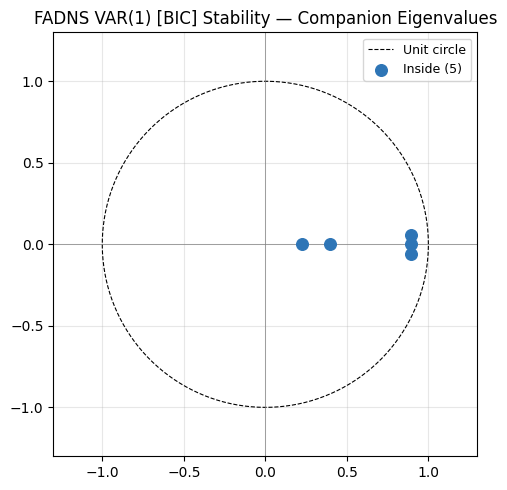

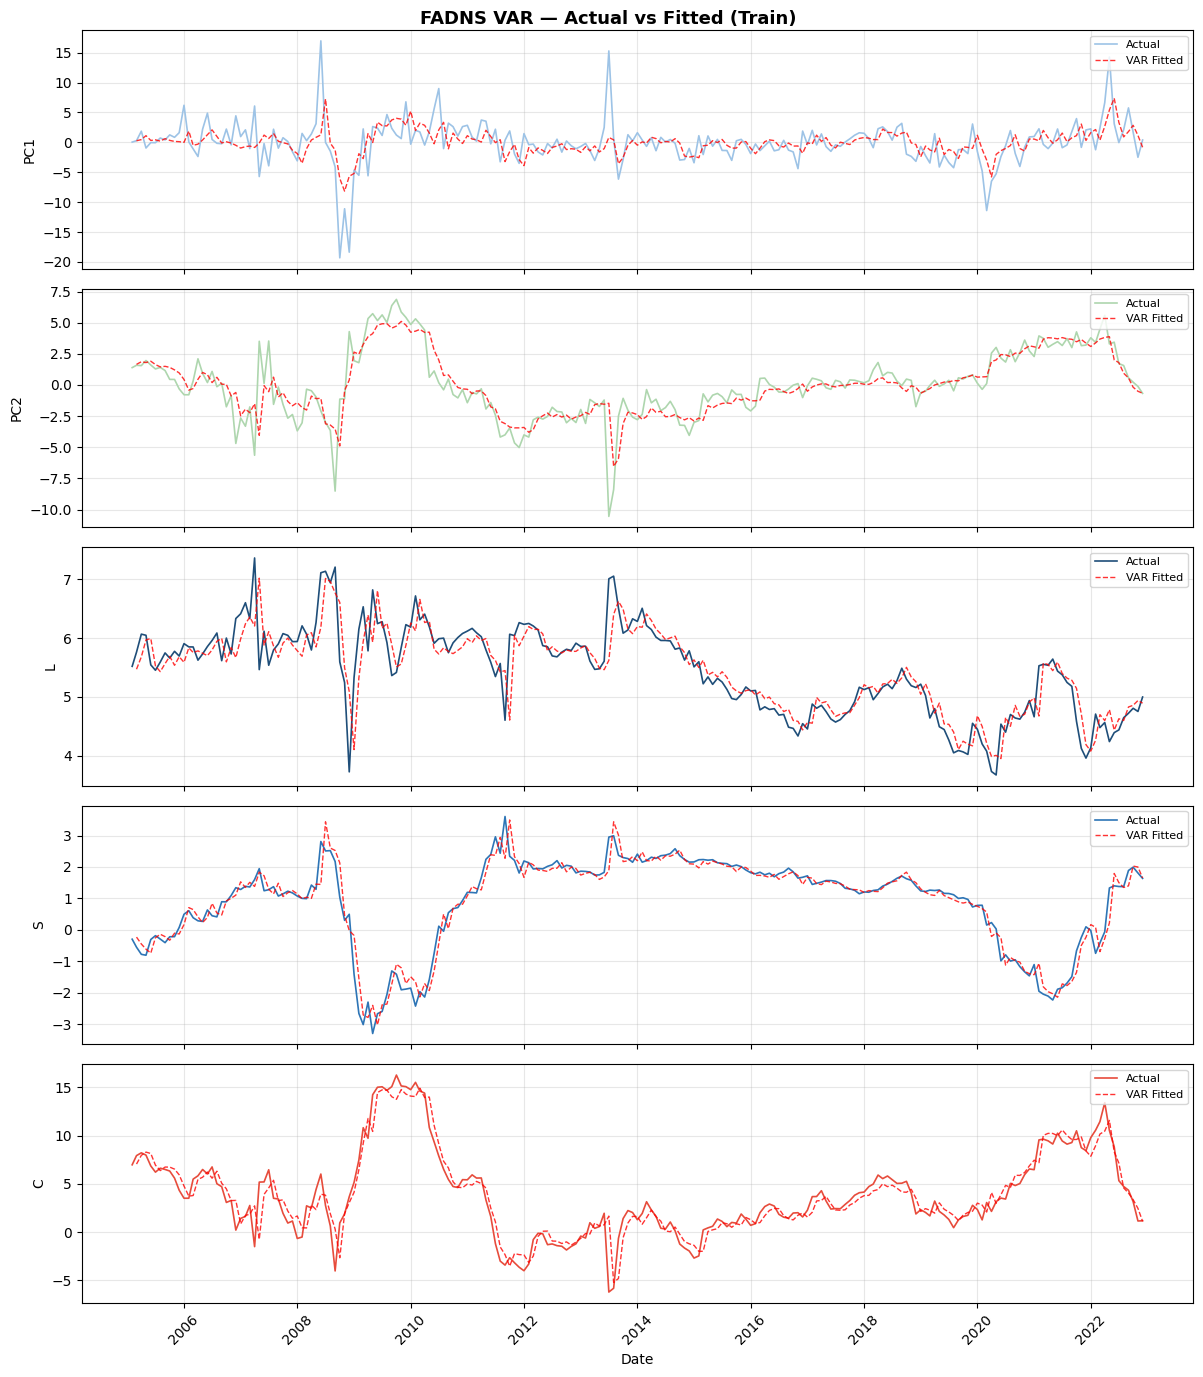


✅  FADNS VAR done (BIC, p=1).


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 9 — FADNS STATE VECTOR & VAR RE-ESTIMATION  (BIC lag)
#  X_t = [PC1, PC2, L, S, C]
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 7: Building FADNS state vector & re-estimating VAR (BIC)")
print("=" * 60)

common_idx = factors_train.index.intersection(macro_pca.index)
print(f"\n  Common dates: {len(common_idx)}  "
      f"({common_idx[0].date()} → {common_idx[-1].date()})")

state_train = pd.concat([
    macro_pca.loc[common_idx, ["PC1", "PC2"]],
    factors_train.loc[common_idx, ["L", "S", "C"]]
], axis=1).dropna()
print(f"  State vector shape: {state_train.shape}  Columns: {list(state_train.columns)}")
print(state_train.head().round(4))

# Lag selection on its own throwaway instance
fadns_lag_result = VAR(state_train).select_order(maxlags=6)
print("\n  Lag order selection (FADNS — 5 variables):")
print(fadns_lag_result.summary())

fadns_best_lag_aic = max(fadns_lag_result.aic, 1)
fadns_best_lag     = max(fadns_lag_result.bic, 1)   # BIC — used for forecasting
print(f"\n  AIC selects lag = {fadns_best_lag_aic}")
print(f"  BIC selects lag = {fadns_best_lag}   ← used for forecasting")

# FIX: fresh instance for the fit (separate from the select_order instance)
fadns_var_result = VAR(state_train).fit(maxlags=fadns_best_lag, ic=None)
print(fadns_var_result.summary())

A_fadns = fadns_var_result.coefs[0]
print(f"\nLag-1 coefficient matrix A1 (descriptive, FADNS lag={fadns_best_lag}):")
print(pd.DataFrame(A_fadns,
                   index=[f"{v} eq" for v in state_train.columns],
                   columns=[f"{v}(-1)" for v in state_train.columns]).round(4).to_string())

eigenvalues_fadns, moduli_fadns, is_stable_fadns = stability_report(
    fadns_var_result, label=f"FADNS VAR({fadns_best_lag}) [BIC]")

fig, ax = plt.subplots(figsize=(5, 5))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=0.8, label="Unit circle")
inside_f = moduli_fadns < 1
ax.scatter(eigenvalues_fadns[inside_f].real, eigenvalues_fadns[inside_f].imag,
           color="#2E75B6", zorder=5, s=70, label=f"Inside ({inside_f.sum()})")
if (~inside_f).any():
    ax.scatter(eigenvalues_fadns[~inside_f].real, eigenvalues_fadns[~inside_f].imag,
               color="#E74C3C", zorder=6, s=90, marker="X", label=f"OUTSIDE ({(~inside_f).sum()})")
lim = max(1.3, moduli_fadns.max() * 1.15)
ax.axhline(0, color="grey", linewidth=0.5); ax.axvline(0, color="grey", linewidth=0.5)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_title(f"FADNS VAR({fadns_best_lag}) [BIC] Stability — Companion Eigenvalues")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

fadns_fitted = fadns_var_result.fittedvalues
fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
fig.suptitle("FADNS VAR — Actual vs Fitted (Train)", fontsize=13, fontweight="bold")
plot_colors = ["#9DC3E6", "#AED6AE", "#1F4E79", "#2E75B6", "#E74C3C"]
for ax, col, color in zip(axes, state_train.columns, plot_colors):
    ax.plot(state_train.index, state_train[col], color=color, linewidth=1.2, label="Actual")
    ax.plot(fadns_fitted.index, fadns_fitted[col], color="red", linewidth=1.0,
            linestyle="--", alpha=0.8, label="VAR Fitted")
    ax.set_ylabel(col, fontsize=10); ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f"\n✅  FADNS VAR done (BIC, p={fadns_best_lag}).")


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 10 — FORECASTING  (static + expanding window, h = 3, 6, 12)
#
#  Models produced:
#    RW            random walk (ŷ_{t+h} = ŷ_t)
#    AR(1)         per-maturity AR(1)
#    DNS-BIC       VAR[L,S,C] BIC lag — static (train-only fit)
#    DNS-BIC-exp   VAR[L,S,C] BIC lag — EXPANDING (refit each origin)
#    DNS-AIC-exp   VAR[L,S,C] AIC lag — EXPANDING (AIC vs BIC check, real-time)
#    FADNS         VAR[PC1,PC2,L,S,C] BIC lag — static
#    FADNS-exp     VAR[PC1,PC2,L,S,C] BIC lag — EXPANDING
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ar_model import AutoReg

print("\n" + "=" * 60)
print("  STEP 8: Forecasting (static + expanding window)")
print("=" * 60)

HORIZONS   = [3, 6, 12]
MAX_H      = max(HORIZONS)
mats_array = np.asarray(maturities, dtype=float)
REFIT_LAG  = False   # expanding window: False = fixed train lag; True = re-select BIC per window

# ── Test macro factors (TRAIN-fitted scaler & PCA — no look-ahead) ───────────
macro_test = macro_raw.loc[(macro_raw.index >= yields_test.index[0]) &
                           (macro_raw.index <= yields_test.index[-1])].copy()
macro_test = macro_test.ffill()[macro_train_orig.columns]

macro_test_stat = {}
for col in macro_train.columns:
    t = translog[col]
    if   t == "none":       macro_test_stat[col] = macro_test[col]
    elif t == "log_return": macro_test_stat[col] = np.log(macro_test[col]).diff()
    elif t == "first_diff": macro_test_stat[col] = macro_test[col].diff()
macro_test_stat   = pd.DataFrame(macro_test_stat, index=macro_test.index).dropna()
macro_test_scaled = scaler.transform(macro_test_stat)
macro_pca_test    = pd.DataFrame(pca2.transform(macro_test_scaled),
                                 index=macro_test_stat.index, columns=["PC1", "PC2"])

factors_test = extract_factors(yields_test, maturities)

state_test_common = pd.concat([macro_pca_test, factors_test[["L", "S", "C"]]],
                              axis=1).dropna()
state_all = pd.concat([state_train, state_test_common]).sort_index()

factors_all = pd.concat([factors_train[["L", "S", "C"]],
                         factors_test[["L", "S", "C"]]]).sort_index().dropna()

print(f"  Test state vector : {state_test_common.shape}  "
      f"({state_test_common.index[0].date()} → {state_test_common.index[-1].date()})")


def reconstruct_curve(L, S, C, mats=mats_array, lam=LAMBDA):
    X = ns_loadings(mats, lam)
    return np.array([L, S, C]) @ X.T


# ── STATIC forecaster: one fit on train, applied at every origin ─────────────
def static_var_forecasts(fitted_res, full_data, origin_dates, lag, lsc_pos):
    """Forecast h ahead from each origin using a model already fit on train."""
    iL, iS, iC = lsc_pos
    out = {h: {} for h in HORIZONS}
    for t_date in origin_dates:
        pos = full_data.index.get_loc(t_date)
        if pos < lag:
            continue
        init = full_data.iloc[pos - lag + 1: pos + 1].values
        fc   = fitted_res.forecast(init, steps=MAX_H)
        for h in HORIZONS:
            v = fc[h - 1]
            out[h][t_date] = reconstruct_curve(v[iL], v[iS], v[iC])
    for h in HORIZONS:
        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
    return out


# ── EXPANDING forecaster: refit VAR on all data up to each origin ────────────
def expanding_var_forecasts(full_data, origin_dates, lag, lsc_pos,
                            label="", refit_lag=False, maxlags_cap=6):
    """
    Recursive expanding window. At each origin t, refit VAR on full_data[:t]
    (everything up to and including t — no look-ahead), forecast h ahead.
    A FRESH VAR(window) is built each iteration, so no shared-state issues.
    Refits ONCE per origin (model doesn't depend on h); forecasts MAX_H, slices.
    """
    iL, iS, iC = lsc_pos
    out = {h: {} for h in HORIZONS}
    n_fit = n_skip = 0
    for t_date in origin_dates:
        try:
            pos = full_data.index.get_loc(t_date)
        except KeyError:
            n_skip += 1; continue
        window = full_data.iloc[:pos + 1]
        if refit_lag:
            try:
                sel = VAR(window).select_order(maxlags=min(maxlags_cap, len(window) // 4))
                this_lag = max(sel.bic, 1)
            except Exception:
                this_lag = lag
        else:
            this_lag = lag
        if len(window) < this_lag + 3:
            n_skip += 1; continue
        try:
            res  = VAR(window).fit(maxlags=this_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)
        except Exception:
            n_skip += 1; continue
        n_fit += 1
        for h in HORIZONS:
            v = fc[h - 1]
            out[h][t_date] = reconstruct_curve(v[iL], v[iS], v[iC])
    for h in HORIZONS:
        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
    print(f"  {label:12s}: refit {n_fit} windows, skipped {n_skip}  "
          f"(lag {'re-selected' if refit_lag else f'fixed={lag}'})")
    return out


# ── DNS-BIC: static + expanding ──────────────────────────────────────────────
print("\n  DNS-BIC static + expanding...")
dns_forecasts     = static_var_forecasts(var_result, factors_all, factors_test.index,
                                         best_lag, (0, 1, 2))
dns_forecasts_exp = expanding_var_forecasts(factors_all, factors_test.index,
                                            best_lag, (0, 1, 2),
                                            label="DNS-BIC", refit_lag=REFIT_LAG)

# ── DNS-AIC: expanding (real-time AIC vs BIC check) ──────────────────────────
print("  DNS-AIC expanding...")
dns_forecasts_aic_exp = expanding_var_forecasts(factors_all, factors_test.index,
                                                best_lag_aic, (0, 1, 2),
                                                label="DNS-AIC", refit_lag=REFIT_LAG)

# ── FADNS: static + expanding ────────────────────────────────────────────────
print("  FADNS static + expanding...")
fadns_forecasts     = static_var_forecasts(fadns_var_result, state_all,
                                           state_test_common.index,
                                           fadns_best_lag, (2, 3, 4))
fadns_forecasts_exp = expanding_var_forecasts(state_all, state_test_common.index,
                                              fadns_best_lag, (2, 3, 4),
                                              label="FADNS", refit_lag=REFIT_LAG)

# ── RW benchmark ─────────────────────────────────────────────────────────────
rw_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        if t_date in yields_test.index:
            rw_forecasts[h][t_date] = yields_test.loc[t_date].values
        else:
            pos = min(yields_test.index.searchsorted(t_date), len(yields_test) - 1)
            rw_forecasts[h][t_date] = yields_test.iloc[pos].values
    rw_forecasts[h] = pd.DataFrame(rw_forecasts[h], index=mats_array).T
    rw_forecasts[h].index.name = "Date"

# ── AR(1) per maturity benchmark ─────────────────────────────────────────────
ar_models = {col: AutoReg(yields_train[col].dropna(), lags=1).fit()
             for col in yields_train.columns}
ar_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        yhat = []
        for col in yields_train.columns:
            if t_date in yields_test.index:
                last_val = yields_test.loc[t_date, col]
            else:
                pos = min(yields_test.index.searchsorted(t_date), len(yields_test) - 1)
                last_val = yields_test.iloc[pos][col]
            # FIX: .iloc positional access (params is a label-indexed Series on pandas 2.x)
            phi0, phi1 = ar_models[col].params.iloc[0], ar_models[col].params.iloc[1]
            yhat.append(phi0 * (1 - phi1**h) / (1 - phi1 + 1e-12) + phi1**h * last_val)
        ar_forecasts[h][t_date] = np.array(yhat)
    ar_forecasts[h] = pd.DataFrame(ar_forecasts[h], index=mats_array).T
    ar_forecasts[h].index.name = "Date"

print("\n  Benchmarks (RW, AR(1)) done.")
for h in HORIZONS:
    print(f"    h={h:2d}: DNS-BIC stat {dns_forecasts[h].shape} / exp {dns_forecasts_exp[h].shape}, "
          f"FADNS stat {fadns_forecasts[h].shape} / exp {fadns_forecasts_exp[h].shape}")


# ── Align actuals at t+h ─────────────────────────────────────────────────────
def get_actual_at_horizon(forecast_df, yields_test, h):
    rows = {}
    for t_date in forecast_df.index:
        future  = t_date + pd.DateOffset(months=h)
        diffs   = np.abs((yields_test.index - future).days)
        nearest = yields_test.index[diffs.argmin()]
        if diffs.min() <= 45:
            rows[t_date] = yields_test.loc[nearest].values
    return pd.DataFrame(rows, index=mats_array).T


actual_h = {}
for h in HORIZONS:
    actual_h[h] = get_actual_at_horizon(fadns_forecasts[h], yields_test, h)
    print(f"  Actuals at h={h:2d}: {actual_h[h].shape}")



  STEP 8: Forecasting (static + expanding window)
  Test state vector : (31, 5)  (2023-02-01 → 2025-08-01)

  DNS-BIC static + expanding...
  DNS-BIC     : refit 38 windows, skipped 0  (lag fixed=1)
  DNS-AIC expanding...


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmod

  DNS-AIC     : refit 38 windows, skipped 0  (lag fixed=2)
  FADNS static + expanding...
  FADNS       : refit 31 windows, skipped 0  (lag fixed=1)

  Benchmarks (RW, AR(1)) done.
    h= 3: DNS-BIC stat (38, 7) / exp (38, 7), FADNS stat (31, 7) / exp (31, 7)
    h= 6: DNS-BIC stat (38, 7) / exp (38, 7), FADNS stat (31, 7) / exp (31, 7)
    h=12: DNS-BIC stat (38, 7) / exp (38, 7), FADNS stat (31, 7) / exp (31, 7)
  Actuals at h= 3: (31, 7)
  Actuals at h= 6: (31, 7)
  Actuals at h=12: (26, 7)


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no


  STEP 9: Evaluation

───────────────────────────────────────────────────────
  Horizon h = 3 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.2707  0.2805   0.2761       0.2685       0.2654  0.2494     0.2524
0.5Y   0.2743  0.2845   0.3029       0.2983       0.2949  0.2739     0.2763
0.75Y  0.2905  0.3001   0.3252       0.3225       0.3169  0.2942     0.2963
1.0Y   0.3049  0.3137   0.3370       0.3347       0.3268  0.3039     0.3057
2.0Y   0.3140  0.3208   0.3328       0.3444       0.3813  0.4090     0.4063
5.0Y   0.3160  0.3259   0.3165       0.3226       0.3537  0.3900     0.3816
10.0Y  0.2805  0.3001   0.2675       0.2687       0.2719  0.2853     0.2752

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.1813  0.1893   0.2250       0.2200       0.2150  0.1958     0.1971
0.5Y   0.2035  0.2179   0.2453       0.2430   

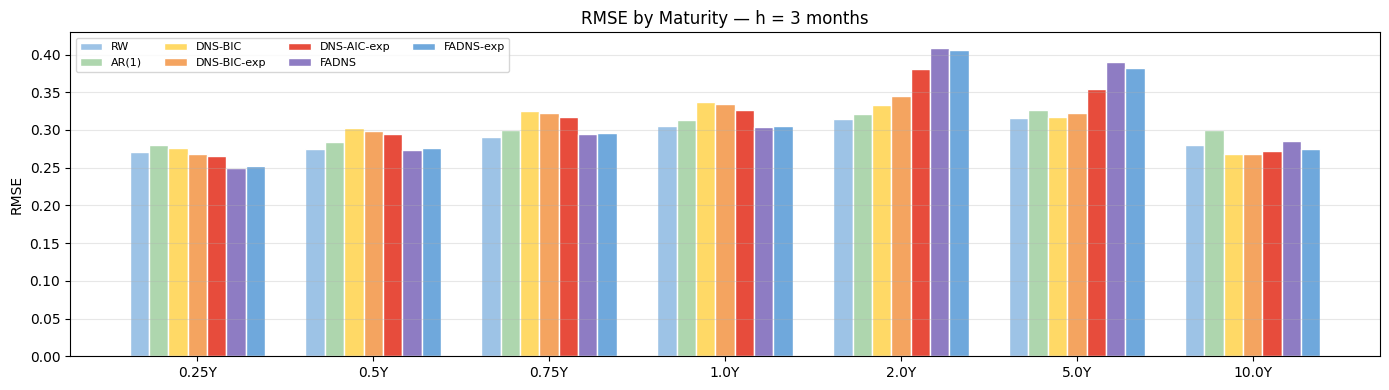


───────────────────────────────────────────────────────
  Horizon h = 6 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.4446  0.4572   0.3899       0.3858       0.3844  0.3528     0.3640
0.5Y   0.4308  0.4498   0.3950       0.3948       0.4028  0.3725     0.3833
0.75Y  0.4229  0.4462   0.3993       0.4015       0.4143  0.3864     0.3967
1.0Y   0.4192  0.4440   0.3998       0.4023       0.4150  0.3883     0.3977
2.0Y   0.3716  0.3999   0.3447       0.3671       0.4507  0.4610     0.4683
5.0Y   0.3223  0.3704   0.3048       0.3170       0.3955  0.4254     0.4171
10.0Y  0.2914  0.3567   0.2516       0.2468       0.3025  0.3399     0.3098

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.3000  0.3181   0.3123       0.3006       0.2963  0.2754     0.2855
0.5Y   0.3068  0.3252   0.3098       0.2983       0.3006  0.2917    

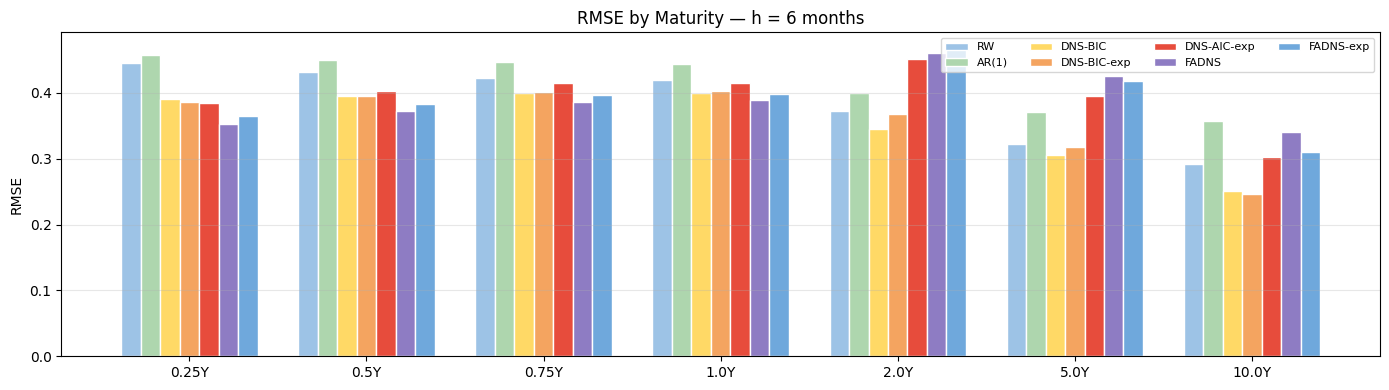


───────────────────────────────────────────────────────
  Horizon h = 12 months — RMSE by maturity
───────────────────────────────────────────────────────

  RMSE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.7756  0.7304   0.5156       0.5395       0.5962  0.5669     0.6010
0.5Y   0.7761  0.7544   0.5137       0.5411       0.6082  0.5810     0.6141
0.75Y  0.7662  0.7533   0.5073       0.5364       0.6082  0.5840     0.6159
1.0Y   0.7530  0.7496   0.4994       0.5280       0.5984  0.5772     0.6071
2.0Y   0.6101  0.6426   0.4607       0.5014       0.6382  0.6374     0.6609
5.0Y   0.4530  0.5735   0.4095       0.4274       0.5547  0.5877     0.5839
10.0Y  0.3952  0.5554   0.4043       0.3871       0.4782  0.5447     0.5074

  MAE:
           RW   AR(1)  DNS-BIC  DNS-BIC-exp  DNS-AIC-exp   FADNS  FADNS-exp
0.25Y  0.6135  0.5663   0.4587       0.4776       0.5048  0.4725     0.4999
0.5Y   0.6407  0.6025   0.4546       0.4819       0.5149  0.4871   

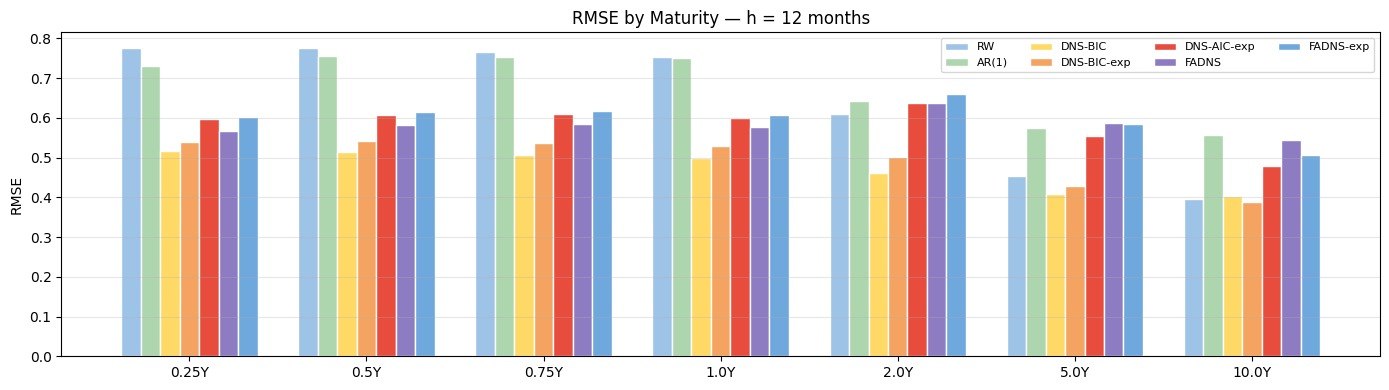


  SUMMARY — Average RMSE across maturities (lower = better)
                h=3     h=6    h=12
RW           0.2930  0.3861  0.6470
AR(1)        0.3037  0.4177  0.6799
DNS-BIC      0.3083  0.3550  0.4729
DNS-BIC-exp  0.3085  0.3593  0.4944
DNS-AIC-exp  0.3158  0.3950  0.5832
FADNS        0.3151  0.3895  0.5827
FADNS-exp    0.3134  0.3910  0.5986

  STATIC vs EXPANDING (Δ = static − expanding; +ve → expanding wins):
    h= 3m  DNS-BIC Δ=-0.0002 → static ✅   |  FADNS Δ=+0.0017 → expanding ✅
    h= 6m  DNS-BIC Δ=-0.0043 → static ✅   |  FADNS Δ=-0.0015 → static ✅
    h=12m  DNS-BIC Δ=-0.0215 → static ✅   |  FADNS Δ=-0.0159 → static ✅

  AIC vs BIC (expanding, DNS):
    h= 3m  AIC=0.3158 | BIC=0.3085 → BIC ✅
    h= 6m  AIC=0.3950 | BIC=0.3593 → BIC ✅
    h=12m  AIC=0.5832 | BIC=0.4944 → BIC ✅

  FADNS vs DNS vs RW (expanding where available):
    h= 3m  RW=0.2930 | DNS-exp=0.3085 | FADNS-exp=0.3134
    h= 6m  RW=0.3861 | DNS-exp=0.3593 | FADNS-exp=0.3910
    h=12m  RW=0.6470 | DNS-exp=0.49

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11 — EVALUATION  (RMSE / MAE; AIC-vs-BIC + static-vs-expanding)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 9: Evaluation")
print("=" * 60)

def compute_metrics(forecast_df, actual_df):
    common = forecast_df.index.intersection(actual_df.index)
    if len(common) == 0:
        return None, None
    f = forecast_df.loc[common].values.astype(float)
    a = actual_df.loc[common].values.astype(float)
    rmse = np.sqrt(np.nanmean((f - a) ** 2, axis=0))
    mae  = np.nanmean(np.abs(f - a), axis=0)
    return rmse, mae


model_forecasts = {
    "RW"          : rw_forecasts,
    "AR(1)"       : ar_forecasts,
    "DNS-BIC"     : dns_forecasts,            # static
    "DNS-BIC-exp" : dns_forecasts_exp,        # expanding
    "DNS-AIC-exp" : dns_forecasts_aic_exp,    # expanding (AIC)
    "FADNS"       : fadns_forecasts,          # static
    "FADNS-exp"   : fadns_forecasts_exp,      # expanding
}

mat_labels = [f"{m}Y" for m in mats_array]
avg_rmse_summary = {}

bar_colors = ["#9DC3E6", "#AED6AE", "#FFD966", "#F4A460",
              "#E74C3C", "#8E7CC3", "#6FA8DC"]

for h in HORIZONS:
    print(f"\n{'─'*55}\n  Horizon h = {h} months — RMSE by maturity\n{'─'*55}")
    rmse_table, mae_table = {}, {}
    for name, fc in model_forecasts.items():
        rmse, mae = compute_metrics(fc[h], actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse; mae_table[name] = mae
    rmse_df = pd.DataFrame(rmse_table, index=mat_labels).round(4)
    mae_df  = pd.DataFrame(mae_table,  index=mat_labels).round(4)
    print("\n  RMSE:"); print(rmse_df.to_string())
    print("\n  MAE:");  print(mae_df.to_string())
    avg_rmse_summary[f"h={h}"] = rmse_df.mean().round(4)

    x, width = np.arange(len(mat_labels)), 0.11
    fig, ax = plt.subplots(figsize=(14, 4))
    for i, (name, color) in enumerate(zip(rmse_table.keys(), bar_colors)):
        ax.bar(x + i * width, rmse_table[name], width, label=name,
               color=color, edgecolor="white")
    ax.set_xticks(x + width * (len(rmse_table) - 1) / 2)
    ax.set_xticklabels(mat_labels)
    ax.set_ylabel("RMSE"); ax.set_title(f"RMSE by Maturity — h = {h} months")
    ax.legend(ncol=4, fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("  SUMMARY — Average RMSE across maturities (lower = better)")
print("=" * 60)
summary_df = pd.DataFrame(avg_rmse_summary)
print(summary_df.to_string())

# ── Verdict: static vs expanding (per model), and AIC vs BIC ─────────────────
def a_rmse(fc_dict, h):
    rmse, _ = compute_metrics(fc_dict[h], actual_h[h])
    return np.nan if rmse is None else float(np.mean(rmse))

print("\n  STATIC vs EXPANDING (Δ = static − expanding; +ve → expanding wins):")
for h in HORIZONS:
    d_dns   = a_rmse(dns_forecasts, h)   - a_rmse(dns_forecasts_exp, h)
    d_fadns = a_rmse(fadns_forecasts, h) - a_rmse(fadns_forecasts_exp, h)
    print(f"    h={h:2d}m  DNS-BIC Δ={d_dns:+.4f} → {'expanding ✅' if d_dns>0 else 'static ✅'}"
          f"   |  FADNS Δ={d_fadns:+.4f} → {'expanding ✅' if d_fadns>0 else 'static ✅'}")

print("\n  AIC vs BIC (expanding, DNS):")
for h in HORIZONS:
    aic_r = a_rmse(dns_forecasts_aic_exp, h)
    bic_r = a_rmse(dns_forecasts_exp,     h)
    print(f"    h={h:2d}m  AIC={aic_r:.4f} | BIC={bic_r:.4f} → "
          f"{'BIC ✅' if bic_r < aic_r else 'AIC ✅'}")

print("\n  FADNS vs DNS vs RW (expanding where available):")
for h in HORIZONS:
    print(f"    h={h:2d}m  RW={a_rmse(rw_forecasts,h):.4f} | "
          f"DNS-exp={a_rmse(dns_forecasts_exp,h):.4f} | "
          f"FADNS-exp={a_rmse(fadns_forecasts_exp,h):.4f}")



  STEP 10: Forecast visualisations


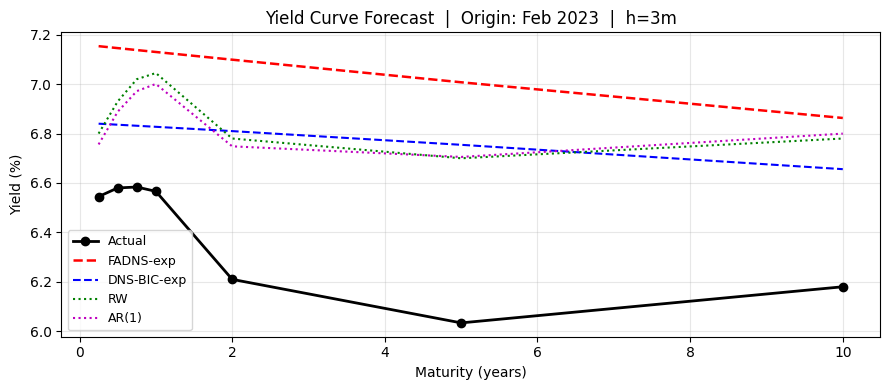

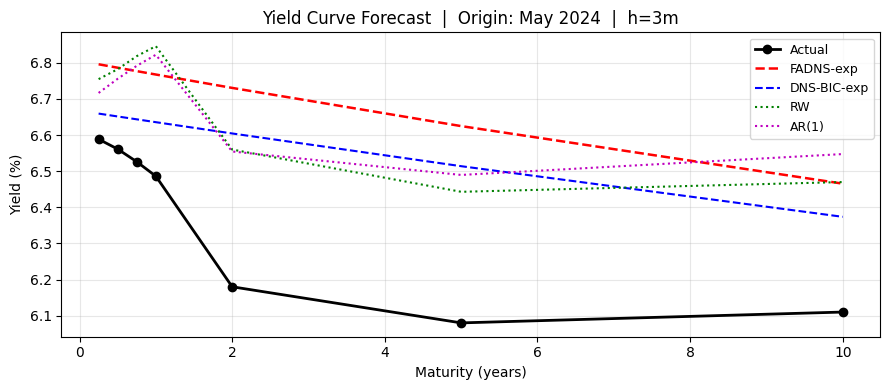

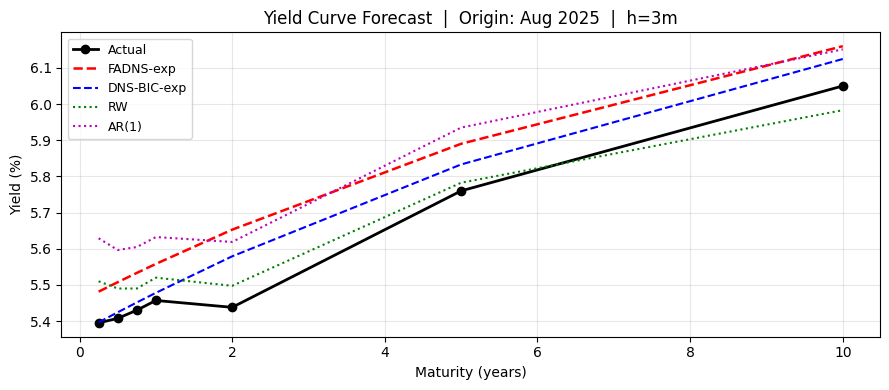

C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no

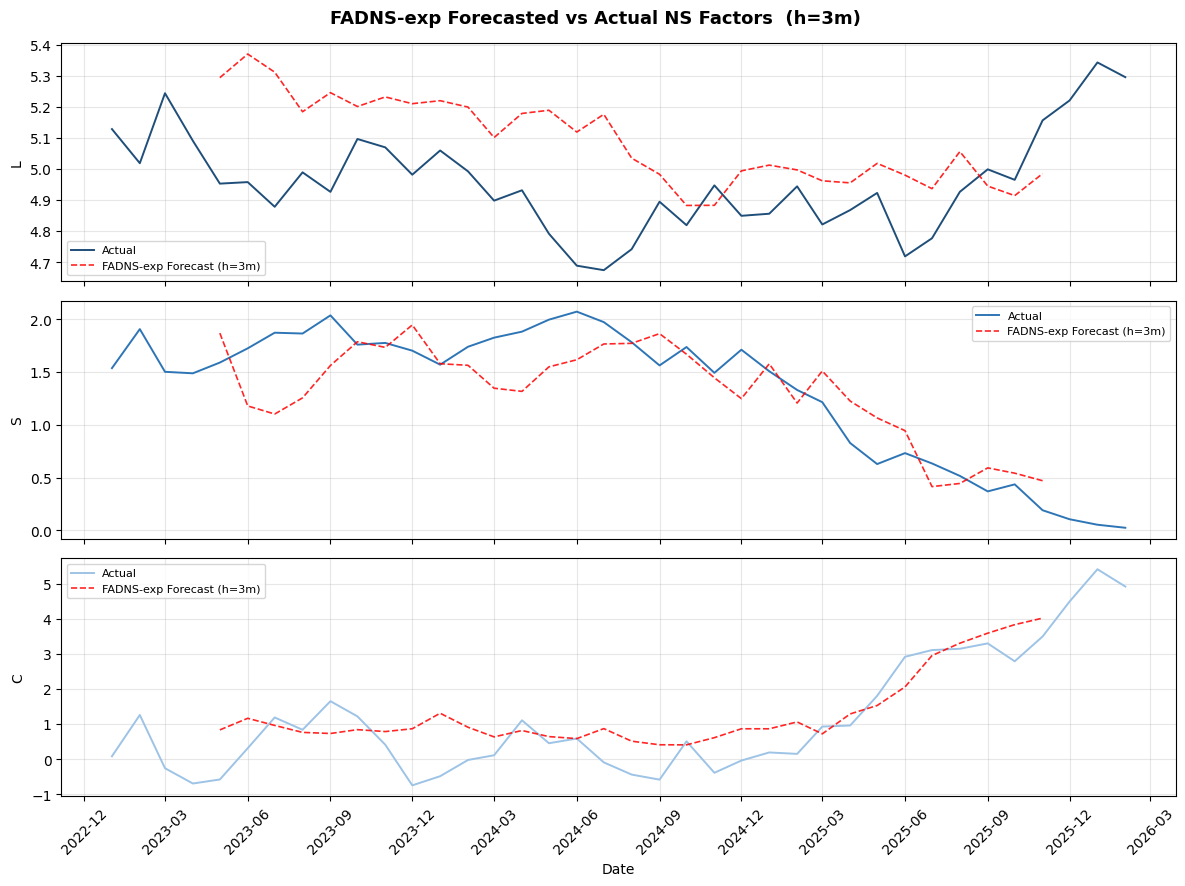


✅  Forecasting & evaluation complete.
    Static : dns_forecasts, fadns_forecasts
    Expand : dns_forecasts_exp, dns_forecasts_aic_exp, fadns_forecasts_exp
    Bench  : rw_forecasts, ar_forecasts   |   actual_h[h]


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 12 — FORECAST VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 10: Forecast visualisations")
print("=" * 60)

h_plot = 3
common = fadns_forecasts_exp[h_plot].index.intersection(actual_h[h_plot].index)
sample = [common[0], common[len(common)//2], common[-1]]

for dt in sample:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mats_array, actual_h[h_plot].loc[dt].values, "ko-", linewidth=2,
            markersize=6, label="Actual")
    ax.plot(mats_array, fadns_forecasts_exp[h_plot].loc[dt].values, "r--",
            linewidth=1.8, label="FADNS-exp")
    ax.plot(mats_array, dns_forecasts_exp[h_plot].loc[dt].values, "b--",
            linewidth=1.5, label="DNS-BIC-exp")
    ax.plot(mats_array, rw_forecasts[h_plot].loc[dt].values, "g:",
            linewidth=1.5, label="RW")
    ax.plot(mats_array, ar_forecasts[h_plot].loc[dt].values, "m:",
            linewidth=1.5, label="AR(1)")
    ax.set_title(f"Yield Curve Forecast  |  Origin: {pd.Timestamp(dt).strftime('%b %Y')}  |  h={h_plot}m")
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

# ── FADNS-exp forecasted L, S, C vs actual (index shifted to t+h) ────────────
fadns_factors_fcast = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in state_test_common.index:
        pos = state_all.index.get_loc(t_date)
        window = state_all.iloc[:pos + 1]
        if len(window) < fadns_best_lag + 3:
            continue
        try:
            res  = VAR(window).fit(maxlags=fadns_best_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)[h - 1]
        except Exception:
            continue
        fadns_factors_fcast[h][t_date] = {"PC1": fc[0], "PC2": fc[1],
                                          "L": fc[2], "S": fc[3], "C": fc[4]}
    fadns_factors_fcast[h] = pd.DataFrame(fadns_factors_fcast[h]).T

h_plot = 3
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"FADNS-exp Forecasted vs Actual NS Factors  (h={h_plot}m)",
             fontsize=13, fontweight="bold")
for ax, col, color in zip(axes, ["L", "S", "C"], ["#1F4E79", "#2E75B6", "#9DC3E6"]):
    ax.plot(factors_test.index, factors_test[col], color=color, linewidth=1.4, label="Actual")
    fcast_col = fadns_factors_fcast[h_plot][col].copy()
    fcast_col.index = fcast_col.index + pd.DateOffset(months=h_plot)  # plot at predicted date
    ax.plot(fcast_col.index, fcast_col.values, color="red", linewidth=1.2,
            linestyle="--", alpha=0.85, label=f"FADNS-exp Forecast (h={h_plot}m)")
    ax.set_ylabel(col, fontsize=10); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].set_xlabel("Date"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print("\n✅  Forecasting & evaluation complete.")
print("    Static : dns_forecasts, fadns_forecasts")
print("    Expand : dns_forecasts_exp, dns_forecasts_aic_exp, fadns_forecasts_exp")
print("    Bench  : rw_forecasts, ar_forecasts   |   actual_h[h]")


  STEP 11: LSTM forecasts (DNS-LSTM, FADNS-LSTM)

  Training DNS-LSTM...
  DNS-LSTM h= 3: trained on 204 seqs, forecast 38 origins.
  DNS-LSTM h= 6: trained on 201 seqs, forecast 38 origins.
  DNS-LSTM h=12: trained on 195 seqs, forecast 38 origins.

  Training FADNS-LSTM...
  FADNS-LSTM h= 3: trained on 201 seqs, forecast 31 origins.
  FADNS-LSTM h= 6: trained on 198 seqs, forecast 31 origins.
  FADNS-LSTM h=12: trained on 192 seqs, forecast 31 origins.

  STEP 12: LSTM vs VAR — RMSE comparison

───────────────────────────────────────────────────────
  Horizon h = 3 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.2707  0.2805       0.2685     0.2524    0.4008      0.4029
0.5Y   0.2743  0.2845       0.2983     0.2763    0.3935      0.4033
0.75Y  0.2905  0.3001       0.3225     0.2963    0.3906      0.4021
1.0Y   0.3049  0.3137       0.3347     0.3057    0.3883      0.3976
2.0

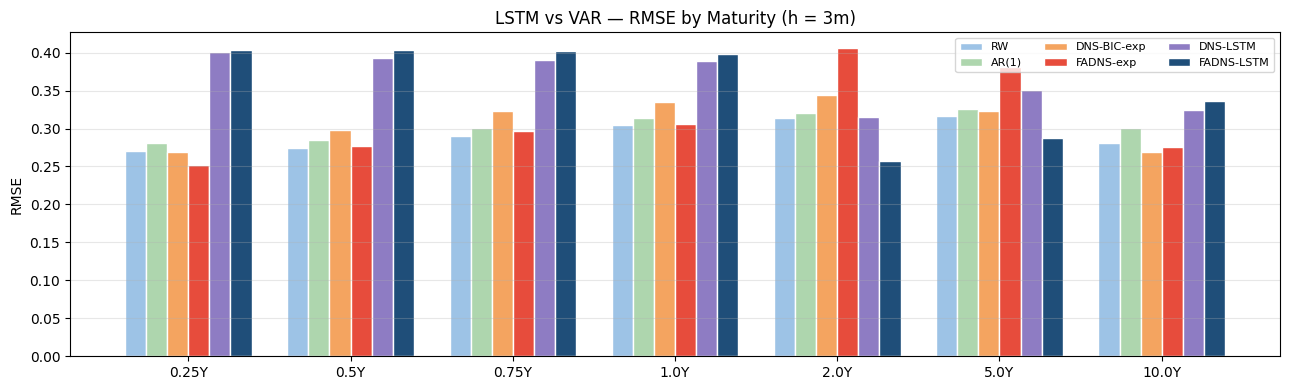


───────────────────────────────────────────────────────
  Horizon h = 6 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.4446  0.4572       0.3858     0.3640    0.6024      0.6883
0.5Y   0.4308  0.4498       0.3948     0.3833    0.5785      0.7153
0.75Y  0.4229  0.4462       0.4015     0.3967    0.5643      0.7337
1.0Y   0.4192  0.4440       0.4023     0.3977    0.5565      0.7430
2.0Y   0.3716  0.3999       0.3671     0.4683    0.3957      0.8147
5.0Y   0.3223  0.3704       0.3170     0.4171    0.3791      0.9111
10.0Y  0.2914  0.3567       0.2468     0.3098    0.3592      1.0483


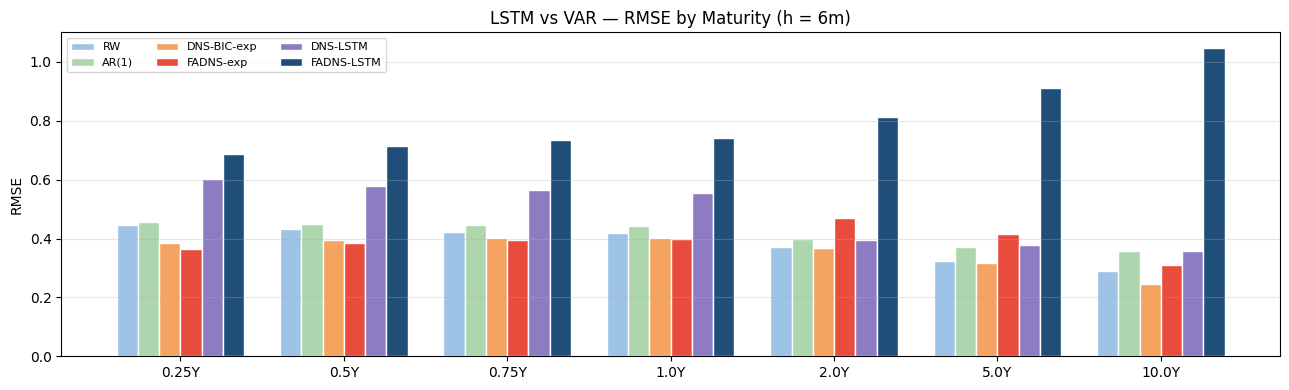


───────────────────────────────────────────────────────
  Horizon h = 12 months — RMSE by maturity
───────────────────────────────────────────────────────
           RW   AR(1)  DNS-BIC-exp  FADNS-exp  DNS-LSTM  FADNS-LSTM
0.25Y  0.7756  0.7304       0.5395     0.6010    1.0261      1.6768
0.5Y   0.7761  0.7544       0.5411     0.6141    1.0202      1.6142
0.75Y  0.7662  0.7533       0.5364     0.6159    1.0028      1.5613
1.0Y   0.7530  0.7496       0.5280     0.6071    0.9871      1.5294
2.0Y   0.6101  0.6426       0.5014     0.6609    0.9103      1.2775
5.0Y   0.4530  0.5735       0.4274     0.5839    0.8147      1.0684
10.0Y  0.3952  0.5554       0.3871     0.5074    0.7874      0.8246


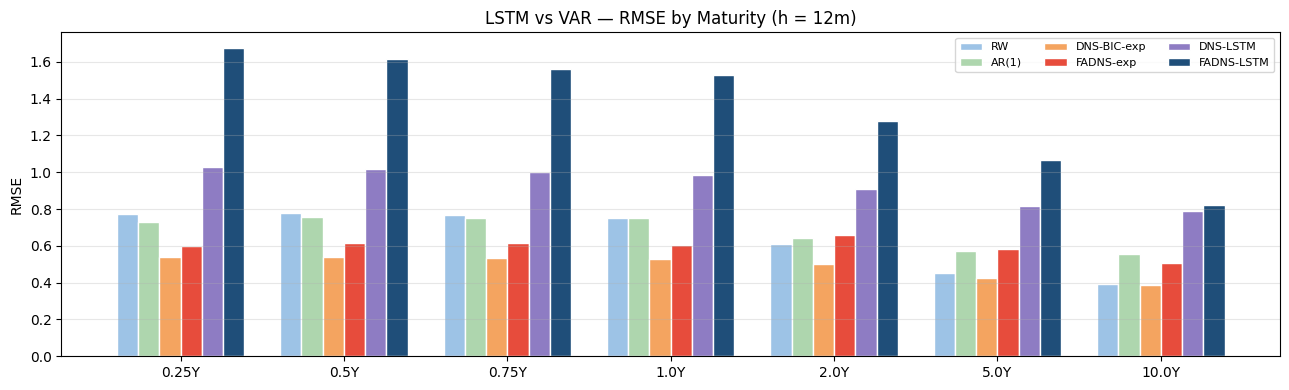


  SUMMARY — Average RMSE across maturities (lower = better)
                h=3     h=6    h=12
RW           0.2930  0.3861  0.6470
AR(1)        0.3037  0.4177  0.6799
DNS-BIC-exp  0.3085  0.3593  0.4944
FADNS-exp    0.3134  0.3910  0.5986
DNS-LSTM     0.3662  0.4908  0.9355
FADNS-LSTM   0.3553  0.8078  1.3646

  LSTM vs its linear VAR counterpart (avg RMSE; +ve Δ → VAR better):
    h= 3m  DNS:  LSTM=0.3662 vs VAR=0.3085  → VAR ✅
           FADNS: LSTM=0.3553 vs VAR=0.3134  → VAR ✅
    h= 6m  DNS:  LSTM=0.4908 vs VAR=0.3593  → VAR ✅
           FADNS: LSTM=0.8077 vs VAR=0.3910  → VAR ✅
    h=12m  DNS:  LSTM=0.9355 vs VAR=0.4944  → VAR ✅
           FADNS: LSTM=1.3646 vs VAR=0.5986  → VAR ✅


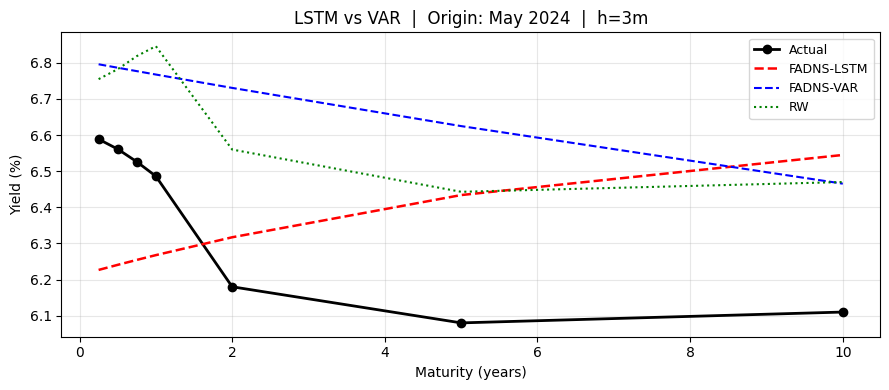


✅  LSTM evaluation complete.
    dns_lstm_forecasts, fadns_lstm_forecasts available per horizon.


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 13 — LSTM FORECASTS  (neural alternative to the VAR dynamics)
#
#  WHERE THIS GOES
#  ---------------
#  Paste at the END of the pipeline, after Section 11 (so actual_h, compute_metrics,
#  reconstruct_curve, factors_train/test/all, state_train/test_common/all,
#  HORIZONS, MAX_H, mats_array all exist).
#
#  IDEA
#  ----
#  DNS/FADNS use a LINEAR VAR to map past factors → future factors. Here we swap
#  that single block for an LSTM and keep EVERYTHING else identical:
#     • same NS factors as features/targets
#     • same horizons h ∈ {3,6,12}
#     • same curve reconstruction (ŷ = L̂ + Ŝ·B1 + Ĉ·B2)
#     • same actual_h targets and the same RMSE/MAE scoring
#  So any RMSE difference is attributable to LINEAR-VAR vs LSTM, nothing else.
#
#  TWO MODELS (mirroring the VAR pair):
#     DNS-LSTM    features = [L, S, C]            → predict [L,S,C] at t+h
#     FADNS-LSTM  features = [PC1, PC2, L, S, C]  → predict [L,S,C] at t+h
#  One LSTM is trained PER HORIZON (direct multi-horizon forecasting).
#
#  HONEST CAVEAT
#  -------------
#  ~178 monthly training rows is extremely small for an LSTM. The net is kept
#  tiny (1 layer, 16 hidden units, dropout, weight decay) to limit overfitting,
#  but do not be surprised if it loses to RW/VAR — that is itself a valid result
#  for a small macro-finance sample. Scheme is STATIC (train once on train,
#  forecast across test) to match the static VAR and stay tractable; an expanding
#  LSTM is possible but means retraining ~40×3 nets.
#
#  REQUIRES: torch  (pip install torch)
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 11: LSTM forecasts (DNS-LSTM, FADNS-LSTM)")
print("=" * 60)

try:
    import torch
    import torch.nn as nn
except ImportError:
    raise SystemExit("PyTorch not installed. Run:  pip install torch")

from sklearn.preprocessing import StandardScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Hyperparameters (tune these) ─────────────────────────────────────────────
LOOKBACK   = 12      # months of history fed to the LSTM (1 year)
HIDDEN     = 16      # LSTM hidden units (small on purpose)
EPOCHS     = 400
LR         = 5e-3
WEIGHT_DEC = 1e-4    # L2 regularisation
DROPOUT    = 0.10
TARGET_COLS = ["L", "S", "C"]


class TinyLSTM(nn.Module):
    """1-layer LSTM → linear head. Predicts the 3 NS factors at horizon h."""
    def __init__(self, n_feat, hidden=HIDDEN, n_out=3, dropout=DROPOUT):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=1, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden, n_out)

    def forward(self, x):
        out, _ = self.lstm(x)          # (batch, seq, hidden)
        last   = out[:, -1, :]         # last timestep
        return self.head(self.drop(last))


def build_sequences(feat_scaled, tgt_scaled, end_positions, lookback, h):
    """
    For each end position i (the forecast origin), build:
      X = feat_scaled[i-lookback+1 : i+1]   (lookback × n_feat)
      y = tgt_scaled[i+h]                   (target factors h steps ahead)
    Only positions with a valid history AND a known target (i+h in range) are used.
    """
    X, y, origins = [], [], []
    n = len(feat_scaled)
    for i in end_positions:
        if i - lookback + 1 < 0 or i + h >= n:
            continue
        X.append(feat_scaled[i - lookback + 1: i + 1])
        y.append(tgt_scaled[i + h])
        origins.append(i)
    if not X:
        return None, None, None
    return (np.asarray(X, dtype=np.float32),
            np.asarray(y, dtype=np.float32),
            origins)


def lstm_forecasts(feat_full_df, origin_dates, train_last_date, label):
    """
    Static LSTM forecasting, one model per horizon.

    feat_full_df    : DataFrame (train+test) with feature columns; MUST include
                      TARGET_COLS among its columns.
    origin_dates    : test origin dates to forecast FROM (same set the VAR used)
    train_last_date : last training date — sequences whose TARGET falls after this
                      are excluded from training (no look-ahead).

    Returns dict: h -> DataFrame (origins × maturities) of forecasted yields.
    """
    feat_cols = list(feat_full_df.columns)
    feat_full = feat_full_df.values.astype(np.float32)
    tgt_idx   = [feat_cols.index(c) for c in TARGET_COLS]

    # position of the last training date in the full frame
    train_last_pos = feat_full_df.index.get_loc(train_last_date)
    # training origins: any i whose history fits and whose target i+h ≤ train end
    train_positions = list(range(len(feat_full_df)))

    out = {h: {} for h in HORIZONS}

    for h in HORIZONS:
        # ----- scalers fit on TRAIN rows only (no leakage) -----
        train_rows = feat_full[:train_last_pos + 1]
        fscaler = StandardScaler().fit(train_rows)
        tscaler = StandardScaler().fit(train_rows[:, tgt_idx])

        feat_scaled = fscaler.transform(feat_full)
        tgt_scaled  = tscaler.transform(feat_full[:, tgt_idx])

        # training sequences: target date must be ≤ train_last_date
        train_ends = [i for i in train_positions if i + h <= train_last_pos]
        Xtr, ytr, _ = build_sequences(feat_scaled, tgt_scaled, train_ends, LOOKBACK, h)
        if Xtr is None or len(Xtr) < 20:
            print(f"  {label} h={h}: too few training sequences ({0 if Xtr is None else len(Xtr)}), skipped.")
            out[h] = pd.DataFrame(index=mats_array).T
            out[h].index.name = "Date"
            continue

        Xtr_t = torch.tensor(Xtr)
        ytr_t = torch.tensor(ytr)

        # ----- train -----
        torch.manual_seed(SEED)
        model = TinyLSTM(n_feat=Xtr.shape[2])
        opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DEC)
        lossf = nn.MSELoss()
        model.train()
        for ep in range(EPOCHS):
            opt.zero_grad()
            pred = model(Xtr_t)
            loss = lossf(pred, ytr_t)
            loss.backward()
            opt.step()

        # ----- forecast each test origin -----
        model.eval()
        with torch.no_grad():
            for t_date in origin_dates:
                try:
                    pos = feat_full_df.index.get_loc(t_date)
                except KeyError:
                    continue
                if pos - LOOKBACK + 1 < 0:
                    continue
                seq = feat_scaled[pos - LOOKBACK + 1: pos + 1]
                seq_t = torch.tensor(seq[np.newaxis, :, :].astype(np.float32))
                yhat_scaled = model(seq_t).numpy().ravel()
                L_h, S_h, C_h = tscaler.inverse_transform(yhat_scaled[np.newaxis, :]).ravel()
                out[h][t_date] = reconstruct_curve(L_h, S_h, C_h)

        out[h] = pd.DataFrame(out[h], index=mats_array).T
        out[h].index.name = "Date"
        print(f"  {label} h={h:2d}: trained on {len(Xtr)} seqs, "
              f"forecast {out[h].shape[0]} origins.")

    return out


# ── Build full feature frames (train+test), aligned like the VAR inputs ──────
# DNS-LSTM features = [L, S, C]
dns_feat_full = factors_all[["L", "S", "C"]].copy()
# FADNS-LSTM features = [PC1, PC2, L, S, C]
fadns_feat_full = state_all[["PC1", "PC2", "L", "S", "C"]].copy()

train_last_date_dns   = factors_train.index[-1]
train_last_date_fadns = state_train.index[-1]

print("\n  Training DNS-LSTM...")
dns_lstm_forecasts = lstm_forecasts(
    dns_feat_full, factors_test.index, train_last_date_dns, label="DNS-LSTM")

print("\n  Training FADNS-LSTM...")
fadns_lstm_forecasts = lstm_forecasts(
    fadns_feat_full, state_test_common.index, train_last_date_fadns, label="FADNS-LSTM")


# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 14 — LSTM vs VAR EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 12: LSTM vs VAR — RMSE comparison")
print("=" * 60)

# Add the two LSTM models to the comparison set (VAR models already exist)
eval_models = {
    "RW"          : rw_forecasts,
    "AR(1)"       : ar_forecasts,
    "DNS-BIC-exp" : dns_forecasts_exp,
    "FADNS-exp"   : fadns_forecasts_exp,
    "DNS-LSTM"    : dns_lstm_forecasts,
    "FADNS-LSTM"  : fadns_lstm_forecasts,
}

mat_labels = [f"{m}Y" for m in mats_array]
lstm_avg_summary = {}

bar_colors2 = ["#9DC3E6", "#AED6AE", "#F4A460", "#E74C3C", "#8E7CC3", "#1F4E79"]

for h in HORIZONS:
    print(f"\n{'─'*55}\n  Horizon h = {h} months — RMSE by maturity\n{'─'*55}")
    rmse_table = {}
    for name, fc in eval_models.items():
        rmse, _ = compute_metrics(fc[h], actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
    rmse_df = pd.DataFrame(rmse_table, index=mat_labels).round(4)
    print(rmse_df.to_string())
    lstm_avg_summary[f"h={h}"] = rmse_df.mean().round(4)

    x, width = np.arange(len(mat_labels)), 0.13
    fig, ax = plt.subplots(figsize=(13, 4))
    for i, (name, color) in enumerate(zip(rmse_table.keys(), bar_colors2)):
        ax.bar(x + i * width, rmse_table[name], width, label=name,
               color=color, edgecolor="white")
    ax.set_xticks(x + width * (len(rmse_table) - 1) / 2)
    ax.set_xticklabels(mat_labels)
    ax.set_ylabel("RMSE"); ax.set_title(f"LSTM vs VAR — RMSE by Maturity (h = {h}m)")
    ax.legend(ncol=3, fontsize=8); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout(); plt.show()

print("\n" + "=" * 60)
print("  SUMMARY — Average RMSE across maturities (lower = better)")
print("=" * 60)
print(pd.DataFrame(lstm_avg_summary).to_string())

print("\n  LSTM vs its linear VAR counterpart (avg RMSE; +ve Δ → VAR better):")
def a_rmse2(fc_dict, h):
    rmse, _ = compute_metrics(fc_dict[h], actual_h[h])
    return np.nan if rmse is None else float(np.mean(rmse))

for h in HORIZONS:
    d_dns   = a_rmse2(dns_lstm_forecasts, h)   - a_rmse2(dns_forecasts_exp, h)
    d_fadns = a_rmse2(fadns_lstm_forecasts, h) - a_rmse2(fadns_forecasts_exp, h)
    print(f"    h={h:2d}m  DNS:  LSTM={a_rmse2(dns_lstm_forecasts,h):.4f} vs "
          f"VAR={a_rmse2(dns_forecasts_exp,h):.4f}  → "
          f"{'VAR ✅' if d_dns>0 else 'LSTM ✅'}")
    print(f"           FADNS: LSTM={a_rmse2(fadns_lstm_forecasts,h):.4f} vs "
          f"VAR={a_rmse2(fadns_forecasts_exp,h):.4f}  → "
          f"{'VAR ✅' if d_fadns>0 else 'LSTM ✅'}")

# ── Sample curve: LSTM vs VAR vs actual at one origin (h=3) ───────────────────
h_plot = 3
common = (dns_lstm_forecasts[h_plot].index
          .intersection(actual_h[h_plot].index)
          .intersection(fadns_lstm_forecasts[h_plot].index))
if len(common):
    dt = common[len(common) // 2]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(mats_array, actual_h[h_plot].loc[dt].values, "ko-", linewidth=2,
            markersize=6, label="Actual")
    ax.plot(mats_array, fadns_lstm_forecasts[h_plot].loc[dt].values, "r--",
            linewidth=1.8, label="FADNS-LSTM")
    ax.plot(mats_array, fadns_forecasts_exp[h_plot].loc[dt].values, "b--",
            linewidth=1.5, label="FADNS-VAR")
    ax.plot(mats_array, rw_forecasts[h_plot].loc[dt].values, "g:",
            linewidth=1.5, label="RW")
    ax.set_title(f"LSTM vs VAR  |  Origin: {pd.Timestamp(dt).strftime('%b %Y')}  |  h={h_plot}m")
    ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print("\n✅  LSTM evaluation complete.")
print("    dns_lstm_forecasts, fadns_lstm_forecasts available per horizon.")


  STEP 10b: DNS expanding vs static — factor-level plots


C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Navya Subba\AppData\Roaming\Python\Python313\site-packages\statsmod

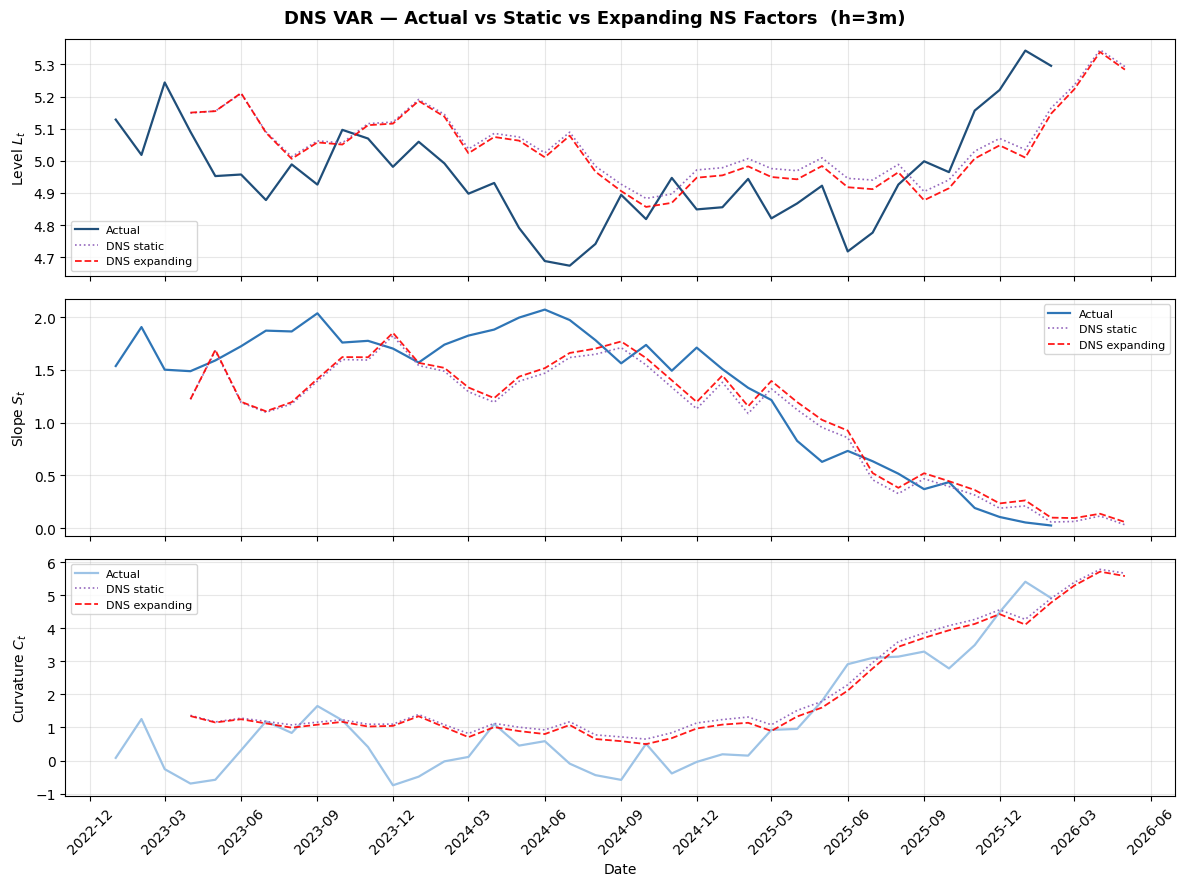


  Mean signed forecast error (forecast − actual) at h=3m:
  factor     static    expanding
  L          0.0915       0.0754   (bias shrinks ✅)
  S         -0.1840      -0.1396   (bias shrinks ✅)
  C          0.6341       0.5160   (bias shrinks ✅)


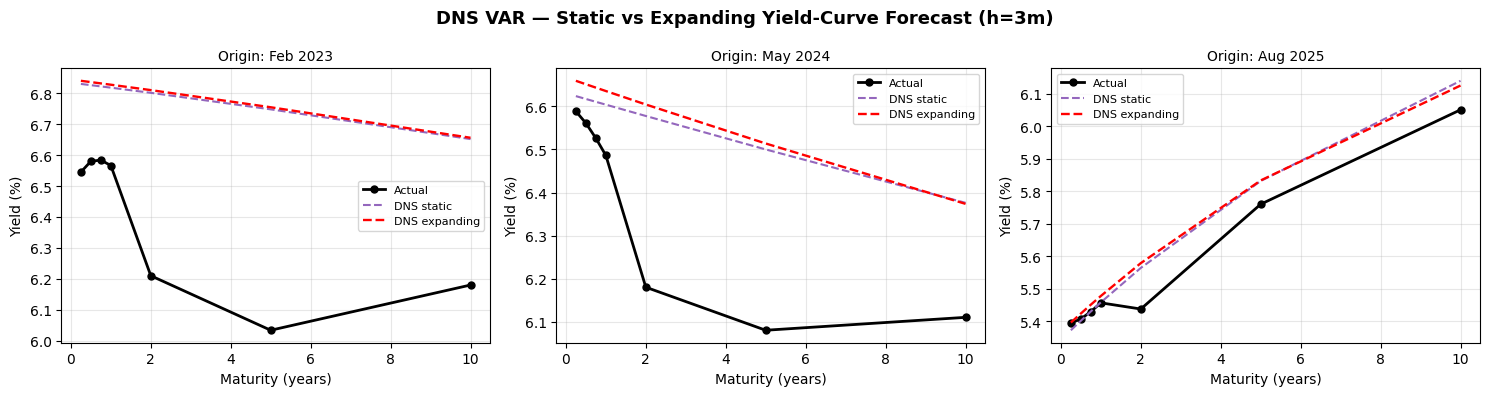


✅  DNS expanding-window plots done.


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 12b — PLOT: DNS EXPANDING-WINDOW VAR  (factor level + curve snapshots)
#
#  Paste after Section 12. Reuses: factors_all, factors_test, var_result,
#  best_lag, VAR, HORIZONS, MAX_H, mats_array, reconstruct_curve, actual_h,
#  dns_forecasts, dns_forecasts_exp, rw_forecasts, factor_colors/labels.
#
#  Purpose: the earlier static plot showed a parallel shift (forecasts pulled to
#  the 2008–2022 mean). This recomputes the DNS forecasts at the FACTOR level for
#  both schemes and overlays them on the actual factors, with the forecast index
#  shifted to t+h (the date each forecast actually predicts), so you can see
#  whether the expanding window pulls the dashed line back toward the actual.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  STEP 10b: DNS expanding vs static — factor-level plots")
print("=" * 60)

H_PLOT = 3   # horizon to visualise (3, 6 or 12)

# ── 1) DNS EXPANDING factor forecasts (refit VAR at each origin) ─────────────
dns_factors_exp = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in factors_test.index:
        pos    = factors_all.index.get_loc(t_date)
        window = factors_all.iloc[:pos + 1]            # data up to & incl. t (no look-ahead)
        if len(window) < best_lag + 3:
            continue
        try:
            res  = VAR(window).fit(maxlags=best_lag, ic=None)
            init = window.values[-res.k_ar:]
            fc   = res.forecast(init, steps=MAX_H)[h - 1]   # (L, S, C) at t+h
        except Exception:
            continue
        dns_factors_exp[h][t_date] = {"L": fc[0], "S": fc[1], "C": fc[2]}
    dns_factors_exp[h] = pd.DataFrame(dns_factors_exp[h]).T

# ── 2) DNS STATIC factor forecasts (one train fit, var_result) ───────────────
dns_factors_static = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in factors_test.index:
        pos = factors_all.index.get_loc(t_date)
        if pos < best_lag:
            continue
        init = factors_all.iloc[pos - best_lag + 1: pos + 1].values
        fc   = var_result.forecast(init, steps=MAX_H)[h - 1]
        dns_factors_static[h][t_date] = {"L": fc[0], "S": fc[1], "C": fc[2]}
    dns_factors_static[h] = pd.DataFrame(dns_factors_static[h]).T

# ── 3) Plot: actual vs DNS-static vs DNS-expanding (index shifted to t+h) ─────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f"DNS VAR — Actual vs Static vs Expanding NS Factors  (h={H_PLOT}m)",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["L", "S", "C"]):
    # actual factors over the test period
    ax.plot(factors_test.index, factors_test[col],
            color=factor_colors[col], linewidth=1.6, label="Actual")

    # static forecast — shift index to the date it predicts (t+h)
    s = dns_factors_static[H_PLOT][col].copy()
    s.index = s.index + pd.DateOffset(months=H_PLOT)
    ax.plot(s.index, s.values, color="#9467BD", linewidth=1.2,
            linestyle=":", label="DNS static")

    # expanding forecast — same shift
    e = dns_factors_exp[H_PLOT][col].copy()
    e.index = e.index + pd.DateOffset(months=H_PLOT)
    ax.plot(e.index, e.values, color="red", linewidth=1.3,
            linestyle="--", alpha=0.9, label="DNS expanding")

    ax.set_ylabel(factor_labels[col], fontsize=10)
    ax.legend(fontsize=8, loc="best"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ── 4) Quantify the parallel shift: mean signed error (bias) per factor ──────
print(f"\n  Mean signed forecast error (forecast − actual) at h={H_PLOT}m:")
print(f"  {'factor':6s} {'static':>10} {'expanding':>12}")
for col in ["L", "S", "C"]:
    a = factors_test[col]
    bias_s, bias_e = [], []
    for src, store in [(dns_factors_static[H_PLOT][col], bias_s),
                       (dns_factors_exp[H_PLOT][col],    bias_e)]:
        for t_date, val in src.items():
            tgt = t_date + pd.DateOffset(months=H_PLOT)
            if tgt in a.index:
                store.append(val - a.loc[tgt])
    ms = np.nanmean(bias_s) if bias_s else np.nan
    me = np.nanmean(bias_e) if bias_e else np.nan
    print(f"  {col:6s} {ms:>10.4f} {me:>12.4f}   "
          f"{'(bias shrinks ✅)' if abs(me) < abs(ms) else '(no improvement)'}")

# ── 5) Yield-curve snapshots: DNS expanding vs static vs actual (h=3) ─────────
common = (dns_forecasts_exp[H_PLOT].index
          .intersection(actual_h[H_PLOT].index)
          .intersection(dns_forecasts[H_PLOT].index))
if len(common):
    sample = [common[0], common[len(common)//2], common[-1]]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"DNS VAR — Static vs Expanding Yield-Curve Forecast (h={H_PLOT}m)",
                 fontsize=13, fontweight="bold")
    for ax, dt in zip(axes, sample):
        ax.plot(mats_array, actual_h[H_PLOT].loc[dt].values, "ko-",
                linewidth=2, markersize=5, label="Actual")
        ax.plot(mats_array, dns_forecasts[H_PLOT].loc[dt].values, "--",
                color="#9467BD", linewidth=1.5, label="DNS static")
        ax.plot(mats_array, dns_forecasts_exp[H_PLOT].loc[dt].values, "r--",
                linewidth=1.7, label="DNS expanding")
        ax.set_title(f"Origin: {pd.Timestamp(dt).strftime('%b %Y')}", fontsize=10)
        ax.set_xlabel("Maturity (years)"); ax.set_ylabel("Yield (%)")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

print("\n✅  DNS expanding-window plots done.")

In [19]:
print("\nOrigin-date overlap check (this should be identical across all models):")
for h in HORIZONS:
    idx_rw    = rw_forecasts[h].index
    idx_dns   = dns_forecasts_exp[h].index
    idx_fadns = fadns_forecasts_exp[h].index
    idx_act   = actual_h[h].index
    print(f"  h={h:2d}: RW={len(idx_rw)}, DNS-exp={len(idx_dns)}, "
          f"FADNS-exp={len(idx_fadns)}, actual={len(idx_act)}")
    common_all = idx_rw.intersection(idx_dns).intersection(idx_fadns).intersection(idx_act)
    print(f"        common to ALL four: {len(common_all)}")


Origin-date overlap check (this should be identical across all models):
  h= 3: RW=31, DNS-exp=38, FADNS-exp=31, actual=31
        common to ALL four: 31
  h= 6: RW=31, DNS-exp=38, FADNS-exp=31, actual=31
        common to ALL four: 31
  h=12: RW=31, DNS-exp=38, FADNS-exp=31, actual=26
        common to ALL four: 26


In [20]:
print("Per-date RMSE breakdown (averaged across maturities), RW vs FADNS-exp vs DNS-exp:")
for h in HORIZONS:
    common = (rw_forecasts[h].index
              .intersection(dns_forecasts_exp[h].index)
              .intersection(fadns_forecasts_exp[h].index)
              .intersection(actual_h[h].index))
    print(f"\n  h={h} months, n={len(common)} common origin dates")
    rows = []
    for t in common:
        a   = actual_h[h].loc[t].values.astype(float)
        rw  = rw_forecasts[h].loc[t].values.astype(float)
        dns = dns_forecasts_exp[h].loc[t].values.astype(float)
        fa  = fadns_forecasts_exp[h].loc[t].values.astype(float)
        rows.append({
            "date": t.date(),
            "RW_err":    np.sqrt(np.mean((rw - a)**2)),
            "DNSexp_err":np.sqrt(np.mean((dns - a)**2)),
            "FADNSexp_err": np.sqrt(np.mean((fa - a)**2)),
        })
    diag = pd.DataFrame(rows).set_index("date")
    print(diag.round(4).to_string())
    print("\n  Mean:", diag.mean().round(4).to_dict())
    print("  How many dates does each model beat RW on?")
    print("   DNS-exp beats RW:  ", (diag["DNSexp_err"] < diag["RW_err"]).sum(), "/", len(diag))
    print("   FADNS-exp beats RW:", (diag["FADNSexp_err"] < diag["RW_err"]).sum(), "/", len(diag))

Per-date RMSE breakdown (averaged across maturities), RW vs FADNS-exp vs DNS-exp:

  h=3 months, n=31 common origin dates
            RW_err  DNSexp_err  FADNSexp_err
date                                        
2023-02-01  0.4980      0.4453        0.7093
2023-03-01  0.0724      0.2299        0.1529
2023-04-01  0.3025      0.5148        0.3131
2023-05-01  0.3975      0.6063        0.3917
2023-06-01  0.3583      0.4903        0.2039
2023-07-01  0.1243      0.1964        0.1383
2023-08-01  0.0710      0.1277        0.1790
2023-09-01  0.4571      0.4291        0.5835
2023-10-01  0.3506      0.3060        0.3393
2023-11-01  0.1434      0.1437        0.1728
2023-12-01  0.1171      0.3192        0.2422
2024-01-01  0.2932      0.4731        0.3061
2024-02-01  0.0847      0.2477        0.1028
2024-03-01  0.0643      0.2044        0.0899
2024-04-01  0.2707      0.2411        0.3951
2024-05-01  0.3157      0.2639        0.3709
2024-06-01  0.3608      0.3192        0.4559
2024-07-01  0.0802     

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11b — DIEBOLD-MARIANO TEST  (RW vs DNS-exp vs FADNS-exp, per horizon)
#
#  Tests whether the difference in forecast accuracy between two models is
#  statistically distinguishable from zero, rather than just comparing mean
#  RMSE on a handful of dates (18-27 obs here, far too few to trust a raw
#  mean comparison). Uses the Harvey-Leybourne-Newbold small-sample correction,
#  recommended whenever n is this small, and a Newey-West variance estimate
#  truncated at lag h-1 (the standard DM choice for h-step-ahead forecasts).
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats


def diebold_mariano(d, h=1, harvey_correction=True):
    """
    Diebold-Mariano test on a pre-computed loss-differential series `d`.

    d_t = L(e1_t) - L(e2_t)   where e1, e2 are the two models' forecast errors
    at each origin date, and L is whatever loss you chose when building `d`
    (squared error, absolute error, etc. — already applied before this call).

    H0: E[d_t] = 0 (no difference in expected loss).
    A positive DM statistic means model 2 has lower loss (more accurate);
    negative means model 1 is more accurate.

    Returns (dm_stat, p_value). p_value uses a Student-t(n-1) reference
    distribution when harvey_correction=True (appropriate for small n),
    else a Normal reference.
    """
    d = np.asarray(d, dtype=float)
    n = len(d)
    d_bar = d.mean()

    # Newey-West (HAC) long-run variance, Bartlett kernel, truncated at h-1
    # (h-step-ahead forecast errors are autocorrelated up to lag h-1 under
    # the null of forecast optimality).
    max_lag = max(h - 1, 0)
    var_d = np.var(d, ddof=0)
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=0)[0, 1]
        var_d += 2 * (1 - lag / (max_lag + 1)) * cov

    var_d = max(var_d, 1e-12)
    dm_stat = d_bar / np.sqrt(var_d / n)

    if harvey_correction:
        correction = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
        dm_stat *= correction
        p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=n - 1))
    else:
        p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


def per_date_rmse(forecast_df, actual_df, common_idx):
    """RMSE across maturities, one scalar per origin date, restricted to common_idx."""
    f = forecast_df.loc[common_idx].values.astype(float)
    a = actual_df.loc[common_idx].values.astype(float)
    return np.sqrt(np.mean((f - a) ** 2, axis=1))


print("\n" + "=" * 70)
print("  DIEBOLD-MARIANO TEST — each model vs Random Walk (RW), per horizon")
print("  Loss = squared, on per-date RMSE-across-maturities series")
print("  (*** p<0.01, ** p<0.05, * p<0.10, blank = not significant)")
print("=" * 70)

dm_rows = []
for h in HORIZONS:
    rw_fc = rw_forecasts[h]
    act   = actual_h[h]

    for name, fc_dict in [("DNS-exp", dns_forecasts_exp),
                          ("FADNS-exp", fadns_forecasts_exp),
                          ("DNS-static", dns_forecasts),
                          ("FADNS-static", fadns_forecasts),
                          ("AR(1)", ar_forecasts)]:
        fc = fc_dict[h]
        common = rw_fc.index.intersection(fc.index).intersection(act.index)
        if len(common) < 5:
            dm_rows.append({"horizon": h, "model": name, "n": len(common),
                            "dm_stat": np.nan, "p_value": np.nan,
                            "verdict": "too few obs"})
            continue

        rw_rmse  = per_date_rmse(rw_fc, act, common)
        mod_rmse = per_date_rmse(fc,    act, common)

        # Loss differential: squared RMSE (= MSE per date) so the loss units
        # match what RMSE tables already report on. d>0 favors `name`.
        d = rw_rmse ** 2 - mod_rmse ** 2

        dm_stat, p_value = diebold_mariano(d, h=h, harvey_correction=True)

        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""

        if p_value < 0.10:
            verdict = f"{name} significantly better" if dm_stat > 0 else "RW significantly better"
        else:
            verdict = "no significant difference"

        dm_rows.append({
            "horizon": h, "model": name, "n": len(common),
            "rw_mean_rmse": round(rw_rmse.mean(), 4),
            "model_mean_rmse": round(mod_rmse.mean(), 4),
            "dm_stat": round(dm_stat, 4), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict
        })

dm_df = pd.DataFrame(dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(dm_df[dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 70)
print("  Reading the table: dm_stat > 0 means the named model beats RW;")
print("  dm_stat < 0 means RW beats the named model. Only trust the verdict")
print("  if sig is *, **, or *** — blank means the difference is statistically")
print("  indistinguishable from zero given how few test-period observations exist.")
print("=" * 70)


  DIEBOLD-MARIANO TEST — each model vs Random Walk (RW), per horizon
  Loss = squared, on per-date RMSE-across-maturities series
  (*** p<0.01, ** p<0.05, * p<0.10, blank = not significant)

--- Horizon h = 3 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_stat  p_value sig                   verdict
     DNS-exp 31        0.2417           0.2708  -0.4190   0.6782     no significant difference
   FADNS-exp 31        0.2417           0.2738  -0.9731   0.3383     no significant difference
  DNS-static 31        0.2417           0.2720  -0.3650   0.7177     no significant difference
FADNS-static 31        0.2417           0.2774  -1.1105   0.2756     no significant difference
       AR(1) 31        0.2417           0.2560  -0.9164   0.3668     no significant difference

--- Horizon h = 6 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_stat  p_value sig                   verdict
     DNS-exp 31        0.3238           0.3020   0.2590   0.7974     no significant 

In [22]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 11b — DIEBOLD-MARIANO TEST  (RW vs DNS-exp vs FADNS-exp, per horizon)
#
#  Tests whether the difference in forecast accuracy between two models is
#  statistically distinguishable from zero, rather than just comparing mean
#  RMSE on a handful of dates (18-27 obs here, far too few to trust a raw
#  mean comparison). Uses the Harvey-Leybourne-Newbold small-sample correction,
#  recommended whenever n is this small, and a Newey-West variance estimate
#  truncated at lag h-1 (the standard DM choice for h-step-ahead forecasts).
# ══════════════════════════════════════════════════════════════════════════════

from scipy import stats


def diebold_mariano(d, h=1, harvey_correction=True):
    """
    Diebold-Mariano test on a pre-computed loss-differential series `d`.

    d_t = L(e1_t) - L(e2_t)   where e1, e2 are the two models' forecast errors
    at each origin date, and L is whatever loss you chose when building `d`
    (squared error here). H0: E[d_t] = 0 (no difference in expected loss).
    A positive DM statistic means model 2 (e2) has lower loss; negative means
    model 1 (e1) is more accurate.

    Uses the Harvey, Leybourne & Newbold (1997) small-sample correction by
    default — essential here since n is only 18-27. HLN rescales the raw DM
    statistic by sqrt((n+1-2h+h(h-1)/n)/n) and references it against a
    Student-t(n-1) distribution instead of Normal, which corrects for the
    over-confidence of the asymptotic test when the forecast horizon h is
    large relative to the sample size n (exactly the regime at h=12, n=18
    here, where the correction factor shrinks to ~0.36).

    Returns (dm_stat, p_value, dm_stat_raw, correction_factor) so both the
    raw and HLN-corrected versions can be reported side by side.
    """
    d = np.asarray(d, dtype=float)
    n = len(d)
    d_bar = d.mean()

    # Newey-West (HAC) long-run variance, Bartlett kernel, truncated at h-1
    # (h-step-ahead forecast errors are autocorrelated up to lag h-1 under
    # the null of forecast optimality).
    max_lag = max(h - 1, 0)
    var_d = np.var(d, ddof=0)
    for lag in range(1, max_lag + 1):
        cov = np.cov(d[lag:], d[:-lag], ddof=0)[0, 1]
        var_d += 2 * (1 - lag / (max_lag + 1)) * cov
    var_d = max(var_d, 1e-12)

    dm_stat_raw = d_bar / np.sqrt(var_d / n)

    if harvey_correction:
        correction = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
        dm_stat = dm_stat_raw * correction
        p_value = 2 * (1 - stats.t.cdf(np.abs(dm_stat), df=n - 1))
    else:
        correction = 1.0
        dm_stat = dm_stat_raw
        p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value, dm_stat_raw, correction


def per_date_rmse(forecast_df, actual_df, common_idx):
    """RMSE across maturities, one scalar per origin date, restricted to common_idx."""
    f = forecast_df.loc[common_idx].values.astype(float)
    a = actual_df.loc[common_idx].values.astype(float)
    return np.sqrt(np.mean((f - a) ** 2, axis=1))


print("\n" + "=" * 90)
print("  DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold corrected) — each model vs RW")
print("  Loss = squared, on per-date RMSE-across-maturities series")
print("  HLN correction is essential here: n is only 18-27 observations,")
print("  and the correction factor shrinks sharply as h grows relative to n")
print("  (e.g. ~0.36 at h=12, n=18) — using uncorrected Normal p-values would")
print("  overstate significance at longer horizons.")
print("  (*** p<0.01, ** p<0.05, * p<0.10 on the HLN-corrected, t-referenced p-value)")
print("=" * 90)

dm_rows = []
for h in HORIZONS:
    rw_fc = rw_forecasts[h]
    act   = actual_h[h]

    for name, fc_dict in [("DNS-exp", dns_forecasts_exp),
                          ("FADNS-exp", fadns_forecasts_exp),
                          ("DNS-static", dns_forecasts),
                          ("FADNS-static", fadns_forecasts),
                          ("AR(1)", ar_forecasts)]:
        fc = fc_dict[h]
        common = rw_fc.index.intersection(fc.index).intersection(act.index)
        if len(common) < 5:
            dm_rows.append({"horizon": h, "model": name, "n": len(common),
                            "dm_raw": np.nan, "dm_hln": np.nan, "hln_corr": np.nan,
                            "p_value": np.nan, "verdict": "too few obs"})
            continue

        rw_rmse  = per_date_rmse(rw_fc, act, common)
        mod_rmse = per_date_rmse(fc,    act, common)

        # Loss differential: squared RMSE (= MSE per date) so the loss units
        # match what the RMSE tables already report. d>0 favors `name`.
        d = rw_rmse ** 2 - mod_rmse ** 2

        dm_hln, p_value, dm_raw, corr = diebold_mariano(d, h=h, harvey_correction=True)

        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""

        if p_value < 0.10:
            verdict = f"{name} sig. better" if dm_hln > 0 else "RW sig. better"
        else:
            verdict = "no significant difference"

        dm_rows.append({
            "horizon": h, "model": name, "n": len(common),
            "rw_mean_rmse": round(rw_rmse.mean(), 4),
            "model_mean_rmse": round(mod_rmse.mean(), 4),
            "dm_raw": round(dm_raw, 4), "dm_hln": round(dm_hln, 4),
            "hln_corr": round(corr, 3), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict
        })

dm_df = pd.DataFrame(dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(dm_df[dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 90)
print("  dm_hln > 0  -> named model beats RW   |   dm_hln < 0 -> RW beats named model")
print("  hln_corr shows how much HLN shrinks the raw statistic — small values")
print("  (e.g. <0.5) signal the asymptotic test would have been overconfident.")
print("  Only trust 'sig. better' verdicts when sig is *, **, or *** — blank means")
print("  the apparent gap is statistically indistinguishable from sampling noise.")
print("=" * 90)


  DIEBOLD-MARIANO TEST (Harvey-Leybourne-Newbold corrected) — each model vs RW
  Loss = squared, on per-date RMSE-across-maturities series
  HLN correction is essential here: n is only 18-27 observations,
  and the correction factor shrinks sharply as h grows relative to n
  (e.g. ~0.36 at h=12, n=18) — using uncorrected Normal p-values would
  overstate significance at longer horizons.
  (*** p<0.01, ** p<0.05, * p<0.10 on the HLN-corrected, t-referenced p-value)

--- Horizon h = 3 months ---
       model  n  rw_mean_rmse  model_mean_rmse  dm_raw  dm_hln  hln_corr  p_value sig                   verdict
     DNS-exp 31        0.2417           0.2708 -0.4559 -0.4190     0.919   0.6782     no significant difference
   FADNS-exp 31        0.2417           0.2738 -1.0586 -0.9731     0.919   0.3383     no significant difference
  DNS-static 31        0.2417           0.2720 -0.3971 -0.3650     0.919   0.7177     no significant difference
FADNS-static 31        0.2417           0.2774 -1.20

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 14 — MODELING THE G-SEC MINUS OIS SPREAD DIRECTLY
#
#  Section 2b built Spread_2Y / Spread_5Y / Spread_10Y (bps) but only used them
#  as a diagnostic. Here we treat the spread itself as a forecasting target,
#  rather than deriving it as the difference of two separately-forecast curves
#  (G-sec and OIS). Same train/test split, monthly resampling, and horizon set
#  as the main curve exercise (Sections 3 & 10), so results are comparable in
#  kind. RMSE/MAE are in bps here, not yield-level units.
#
#  Models: RW (y_hat_{t+h} = y_t) and AR(1) per tenor, evaluated against RW
#  with the same Diebold-Mariano (HLN-corrected) test used in Section 11b.
# ══════════════════════════════════════════════════════════════════════════════

from statsmodels.tsa.ar_model import AutoReg

print("\n" + "=" * 60)
print("  SECTION 14: G-sec - OIS spread -- direct forecasting")
print("=" * 60)

spread_cols = [f"Spread_{t}" for t in ("2Y", "5Y", "10Y")]

# Monthly resample, same cutoff as the main yield split (Section 3)
spread_monthly = spread[spread_cols].resample("MS").last()
spread_train = spread_monthly[spread_monthly.index <= "2022-12-31"]
spread_test  = spread_monthly[spread_monthly.index >  "2022-12-31"]

print(f"  Spread train (monthly): {spread_train.index[0].date()} -> "
      f"{spread_train.index[-1].date()}  ({len(spread_train)} months)")
print(f"  Spread test  (monthly): {spread_test.index[0].date()}  -> "
      f"{spread_test.index[-1].date()}   ({len(spread_test)} months)")

# ── RW benchmark ───────────────────────────────────────────────────────────────
spread_rw_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in spread_test.index:
        spread_rw_forecasts[h][t_date] = spread_test.loc[t_date].values
    spread_rw_forecasts[h] = pd.DataFrame(spread_rw_forecasts[h], index=spread_cols).T
    spread_rw_forecasts[h].index.name = "Date"

# ── AR(1) per tenor ──────────────────────────────────────────────────────────────
spread_ar_models = {col: AutoReg(spread_train[col].dropna(), lags=1).fit()
                     for col in spread_train.columns}

spread_ar_forecasts = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in spread_test.index:
        yhat = []
        for col in spread_train.columns:
            last_val = spread_test.loc[t_date, col]
            phi0 = spread_ar_models[col].params.iloc[0]
            phi1 = spread_ar_models[col].params.iloc[1]
            yhat.append(phi0 * (1 - phi1 ** h) / (1 - phi1 + 1e-12) + phi1 ** h * last_val)
        spread_ar_forecasts[h][t_date] = np.array(yhat)
    spread_ar_forecasts[h] = pd.DataFrame(spread_ar_forecasts[h], index=spread_cols).T
    spread_ar_forecasts[h].index.name = "Date"


# ── Actuals at t+h (same 45-day nearest-match rule as Section 10) ───────────────
def get_actual_at_horizon_spread(forecast_df, test_df, h):
    rows = {}
    for t_date in forecast_df.index:
        future  = t_date + pd.DateOffset(months=h)
        diffs   = np.abs((test_df.index - future).days)
        nearest = test_df.index[diffs.argmin()]
        if diffs.min() <= 45:
            rows[t_date] = test_df.loc[nearest].values
    return pd.DataFrame(rows, index=spread_cols).T


spread_actual_h = {h: get_actual_at_horizon_spread(spread_rw_forecasts[h], spread_test, h)
                    for h in HORIZONS}

# ── Evaluation: RMSE / MAE (reuses compute_metrics from Section 11) ─────────────
spread_model_forecasts = {"RW": spread_rw_forecasts, "AR(1)": spread_ar_forecasts}

spread_rmse_summary = {}
for h in HORIZONS:
    print(f"\n{'-' * 55}\n  Spread -- Horizon h = {h} months -- RMSE by tenor (bps)\n{'-' * 55}")
    rmse_table, mae_table = {}, {}
    for name, fc in spread_model_forecasts.items():
        rmse, mae = compute_metrics(fc[h], spread_actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
            mae_table[name]  = mae
    rmse_df = pd.DataFrame(rmse_table, index=spread_cols).round(2)
    mae_df  = pd.DataFrame(mae_table,  index=spread_cols).round(2)
    print("\n  RMSE (bps):"); print(rmse_df.to_string())
    print("\n  MAE (bps):");  print(mae_df.to_string())
    spread_rmse_summary[f"h={h}"] = rmse_df.mean().round(2)

print("\n" + "=" * 60)
print("  SUMMARY -- Average spread RMSE across tenors (bps, lower = better)")
print("=" * 60)
print(pd.DataFrame(spread_rmse_summary).to_string())

# ── DM test: AR(1) vs RW, per tenor, per horizon (reuses diebold_mariano) ───────
print("\n" + "=" * 90)
print("  DIEBOLD-MARIANO (HLN-corrected) -- Spread AR(1) vs RW, per tenor")
print("  Loss = squared error on the raw spread series (no cross-tenor averaging,")
print("  since each tenor's spread is its own forecasting target here)")
print("  (*** p<0.01, ** p<0.05, * p<0.10)")
print("=" * 90)

spread_dm_rows = []
for h in HORIZONS:
    rw_fc = spread_rw_forecasts[h]
    ar_fc = spread_ar_forecasts[h]
    act   = spread_actual_h[h]
    for col in spread_cols:
        common = rw_fc.index.intersection(ar_fc.index).intersection(act.index)
        if len(common) < 5:
            spread_dm_rows.append({"horizon": h, "tenor": col, "n": len(common),
                                    "dm_hln": np.nan, "p_value": np.nan,
                                    "verdict": "too few obs"})
            continue

        rw_err = rw_fc.loc[common, col].values.astype(float) - act.loc[common, col].values.astype(float)
        ar_err = ar_fc.loc[common, col].values.astype(float) - act.loc[common, col].values.astype(float)

        # d > 0 favors AR(1) (RW loss minus AR(1) loss)
        d = rw_err ** 2 - ar_err ** 2
        dm_hln, p_value, dm_raw, corr = diebold_mariano(d, h=h, harvey_correction=True)

        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""

        if p_value < 0.10:
            verdict = "AR(1) sig. better" if dm_hln > 0 else "RW sig. better"
        else:
            verdict = "no significant difference"

        spread_dm_rows.append({
            "horizon": h, "tenor": col, "n": len(common),
            "rw_rmse": round(np.sqrt(np.mean(rw_err ** 2)), 3),
            "ar_rmse": round(np.sqrt(np.mean(ar_err ** 2)), 3),
            "dm_hln": round(dm_hln, 3), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict,
        })

spread_dm_df = pd.DataFrame(spread_dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(spread_dm_df[spread_dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 90)
print("  dm_hln > 0 -> AR(1) beats RW on the spread  |  dm_hln < 0 -> RW beats AR(1)")
print("  Only trust 'sig. better' verdicts when sig is *, **, or *** .")
print("  If RW wins (or ties) across the board, the G-sec-OIS spread behaves like")
print("  a random walk at monthly frequency and isn't worth modeling beyond the")
print("  level forecasts you already have -- it's just noise around a level.")
print("=" * 90)



  SECTION 14: G-sec - OIS spread -- direct forecasting
  Spread train (monthly): 2008-01-01 -> 2022-12-01  (180 months)
  Spread test  (monthly): 2023-01-01  -> 2026-02-01   (38 months)

-------------------------------------------------------
  Spread -- Horizon h = 3 months -- RMSE by tenor (bps)
-------------------------------------------------------

  RMSE (bps):
               RW  AR(1)
Spread_2Y   17.13  15.81
Spread_5Y   19.77  20.35
Spread_10Y  21.60  22.49

  MAE (bps):
               RW  AR(1)
Spread_2Y   14.42  12.81
Spread_5Y   15.16  15.22
Spread_10Y  16.95  17.45

-------------------------------------------------------
  Spread -- Horizon h = 6 months -- RMSE by tenor (bps)
-------------------------------------------------------

  RMSE (bps):
               RW  AR(1)
Spread_2Y   20.01  17.46
Spread_5Y   21.09  22.76
Spread_10Y  24.42  26.14

  MAE (bps):
               RW  AR(1)
Spread_2Y   16.68  14.44
Spread_5Y   17.35  17.19
Spread_10Y  20.81  19.36

----------------

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 15 — COMPOSED G-SEC FORECAST  (modelled OIS + modelled spread)
#
#  Answers the actual question: instead of building a separate G-sec curve
#  model, can we just forecast OIS (already have DNS/FADNS/RW for that) and
#  forecast the spread (Section 14), then add them back together?
#
#      G-sec_hat(t+h)  =  OIS_hat(t+h)  +  Spread_hat(t+h)      [tenor-by-tenor]
#
#  This only works at the three tenors where a spread series exists: 2Y/5Y/10Y.
#  We compose a few combinations (which OIS model x which spread model) and
#  check the resulting G-sec RMSE against the actual G-sec yields -- plus a
#  naive "RW on G-sec directly" baseline, so we can see whether composing is
#  actually worth it versus just letting G-sec random-walk on its own.
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("  SECTION 15: Composed G-sec forecast (OIS_hat + Spread_hat)")
print("=" * 60)

compose_tenors = [("2Y", 2.00), ("5Y", 5.00), ("10Y", 10.00)]
gsec_cols      = [f"GSEC_{t}" for t, _ in compose_tenors]

# ── Actual G-sec, monthly, same split as everything else ────────────────────────
gsec_monthly = gsec_levels[gsec_cols].resample("MS").last()
gsec_test    = gsec_monthly[gsec_monthly.index > "2022-12-31"]


def get_actual_at_horizon_gsec(origin_dates, test_df, h):
    rows = {}
    for t_date in origin_dates:
        future  = t_date + pd.DateOffset(months=h)
        diffs   = np.abs((test_df.index - future).days)
        nearest = test_df.index[diffs.argmin()]
        if diffs.min() <= 45:
            rows[t_date] = test_df.loc[nearest].values
    return pd.DataFrame(rows, index=gsec_cols).T


actual_gsec_h = {h: get_actual_at_horizon_gsec(spread_test.index, gsec_test, h)
                  for h in HORIZONS}

# ── RW-on-G-sec-directly baseline (no composition, no OIS/spread involved) ──────
gsec_rw_direct = {h: {} for h in HORIZONS}
for h in HORIZONS:
    for t_date in gsec_test.index:
        gsec_rw_direct[h][t_date] = gsec_test.loc[t_date].values
    gsec_rw_direct[h] = pd.DataFrame(gsec_rw_direct[h], index=gsec_cols).T
    gsec_rw_direct[h].index.name = "Date"

# ── OIS forecast sources (already built in Section 10) at 2Y/5Y/10Y only ────────
ois_model_sources = {
    "RW-OIS"          : rw_forecasts,
    "DNS-BIC-exp"     : dns_forecasts_exp,
    "FADNS-exp"       : fadns_forecasts_exp,
}
spread_model_sources = {
    "RW-spread"   : spread_rw_forecasts,
    "AR(1)-spread": spread_ar_forecasts,
}


def compose_gsec_forecast(ois_dict, spread_dict, h):
    """G-sec_hat(t+h) = OIS_hat(t+h) + Spread_hat(t+h), tenor by tenor."""
    common = ois_dict[h].index.intersection(spread_dict[h].index)
    out = {}
    for t_date in common:
        vals = []
        for tenor, mat in compose_tenors:
            ois_hat    = ois_dict[h].loc[t_date, mat]
            spread_hat = spread_dict[h].loc[t_date, f"Spread_{tenor}"] / 100.0  # bps -> level units
            vals.append(ois_hat + spread_hat)
        out[t_date] = np.array(vals)
    df = pd.DataFrame(out, index=gsec_cols).T
    df.index.name = "Date"
    return df


composed_forecasts = {}
for ois_name, ois_dict in ois_model_sources.items():
    for spr_name, spr_dict in spread_model_sources.items():
        key = f"{ois_name} + {spr_name}"
        composed_forecasts[key] = {h: compose_gsec_forecast(ois_dict, spr_dict, h) for h in HORIZONS}

composed_forecasts["RW-on-Gsec (baseline)"] = gsec_rw_direct

# ── Evaluate: RMSE / MAE per composition, per horizon ────────────────────────────
gsec_rmse_summary = {}
for h in HORIZONS:
    print(f"\n{'-' * 60}\n  Composed G-sec -- Horizon h = {h} months -- RMSE by tenor\n{'-' * 60}")
    rmse_table = {}
    for name, fc_dict in composed_forecasts.items():
        rmse, _ = compute_metrics(fc_dict[h], actual_gsec_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
    rmse_df = pd.DataFrame(rmse_table, index=gsec_cols).round(4)
    print(rmse_df.to_string())
    gsec_rmse_summary[f"h={h}"] = rmse_df.mean().round(4)

print("\n" + "=" * 70)
print("  SUMMARY -- Average composed-G-sec RMSE across tenors (lower = better)")
print("  Compare each 'X + Y' row against 'RW-on-Gsec (baseline)':")
print("  beating it means composing modelled-OIS + modelled-spread adds value")
print("  over just letting G-sec random-walk on its own.")
print("=" * 70)
print(pd.DataFrame(gsec_rmse_summary).to_string())

# ── DM test: best composed candidate vs RW-on-Gsec baseline, per tenor/horizon ──
print("\n" + "=" * 90)
print("  DIEBOLD-MARIANO -- best composed model vs RW-on-Gsec baseline, per tenor")
print("  (pick the composition with the lowest average h=3 RMSE from the summary")
print("   above and set BEST_COMPOSITION below if you want a different one)")
print("=" * 90)

def _avg_h3_rmse(key):
    rmse, _ = compute_metrics(composed_forecasts[key][3], actual_gsec_h[3])
    return np.mean(rmse) if rmse is not None else np.inf

BEST_COMPOSITION = min(
    (k for k in composed_forecasts if k != "RW-on-Gsec (baseline)"),
    key=_avg_h3_rmse,
)
print(f"  Comparing: {BEST_COMPOSITION!r}  vs  'RW-on-Gsec (baseline)'\n")

gsec_dm_rows = []
for h in HORIZONS:
    best_fc = composed_forecasts[BEST_COMPOSITION][h]
    rw_fc   = gsec_rw_direct[h]
    act     = actual_gsec_h[h]
    for col in gsec_cols:
        common = best_fc.index.intersection(rw_fc.index).intersection(act.index)
        if len(common) < 5:
            gsec_dm_rows.append({"horizon": h, "tenor": col, "n": len(common),
                                  "dm_hln": np.nan, "p_value": np.nan, "verdict": "too few obs"})
            continue
        best_err = best_fc.loc[common, col].values.astype(float) - act.loc[common, col].values.astype(float)
        rw_err   = rw_fc.loc[common, col].values.astype(float)   - act.loc[common, col].values.astype(float)
        d = rw_err ** 2 - best_err ** 2   # > 0 favors the composed model
        dm_hln, p_value, dm_raw, corr = diebold_mariano(d, h=h, harvey_correction=True)
        if p_value < 0.01:   sig = "***"
        elif p_value < 0.05: sig = "**"
        elif p_value < 0.10: sig = "*"
        else:                sig = ""
        if p_value < 0.10:
            verdict = "composed sig. better" if dm_hln > 0 else "RW-baseline sig. better"
        else:
            verdict = "no significant difference"
        gsec_dm_rows.append({
            "horizon": h, "tenor": col, "n": len(common),
            "rw_rmse": round(np.sqrt(np.mean(rw_err ** 2)), 4),
            "composed_rmse": round(np.sqrt(np.mean(best_err ** 2)), 4),
            "dm_hln": round(dm_hln, 3), "p_value": round(p_value, 4),
            "sig": sig, "verdict": verdict,
        })

gsec_dm_df = pd.DataFrame(gsec_dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(gsec_dm_df[gsec_dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 90)
print("  dm_hln > 0 -> composed (OIS_hat + Spread_hat) beats plain RW-on-Gsec")
print("  dm_hln < 0 -> plain RW-on-Gsec beats the composed approach")
print("  Only trust 'sig. better' when sig is *, **, or ***.")
print("=" * 90)



  SECTION 15: Composed G-sec forecast (OIS_hat + Spread_hat)

------------------------------------------------------------
  Composed G-sec -- Horizon h = 3 months -- RMSE by tenor
------------------------------------------------------------
          RW-OIS + RW-spread  RW-OIS + AR(1)-spread  DNS-BIC-exp + RW-spread  DNS-BIC-exp + AR(1)-spread  FADNS-exp + RW-spread  FADNS-exp + AR(1)-spread  RW-on-Gsec (baseline)
GSEC_2Y               0.3035                 0.2894                   0.3148                      0.3021                 0.4007                    0.3653                 0.2846
GSEC_5Y               0.2738                 0.2928                   0.2835                      0.3031                 0.3783                    0.3856                 0.2559
GSEC_10Y              0.1949                 0.2056                   0.1813                      0.2266                 0.2199                    0.2395                 0.1848

------------------------------------------------

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
#  SECTION 16 — SPREAD MODELLED WITH MACRO FACTORS (TREE ENSEMBLES)
#
#  Extends Section 14: instead of AR(1)/RW on the spread alone, model
#      Spread_tenor(t+h)  ~  f( Spread_tenor(t), PC1(t), PC2(t) )
#  using Random Forest and Gradient Boosting, reusing the SAME macro PC1/PC2
#  factors already extracted in Section 8 (train-fitted scaler + PCA, no
#  look-ahead) -- not a new macro PCA. Own-lag is included as a feature so the
#  model isn't forced to throw away the persistence AR(1) already captures.
#
#  Two fitting regimes, matching the DNS-BIC / DNS-BIC-exp convention already
#  used in Section 10:
#    "*-static"   : one fit on train only, applied to every test origin
#    "*-exp"      : refit at every test origin on all data up to (and
#                   including) that origin, respecting the h-step-ahead
#                   target so no row's label ever depends on the future
#                   relative to that origin (look-ahead check below)
#
#  Evaluated the same way as Section 14 (RMSE/MAE + DM test vs RW & AR(1)),
#  and then fed into Section 15's composition (OIS_hat + Spread_hat) as two
#  more spread-model options.
# ══════════════════════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("\n" + "=" * 60)
print("  SECTION 16: Spread vs macro factors (RF / GBM)")
print("=" * 60)

# ── Combine spread with the macro PCs already built in Sections 8 & 10 ──────────
# macro_pca (train) and state_test_common[["PC1","PC2"]] (test) both come from
# the SAME train-fitted scaler/PCA -- reusing them, not re-fitting.
macro_pca_all = pd.concat(
    [macro_pca[["PC1", "PC2"]], state_test_common[["PC1", "PC2"]]]
).sort_index()
macro_pca_all = macro_pca_all[~macro_pca_all.index.duplicated(keep="last")]

combined_df = pd.concat([spread_monthly, macro_pca_all], axis=1, join="inner").dropna()
print(f"  Combined spread+macro dataset: {combined_df.shape}  "
      f"({combined_df.index[0].date()} -> {combined_df.index[-1].date()})")

TRAIN_CUTOFF = pd.Timestamp("2022-12-31")
MIN_TRAIN_ROWS = 24   # need at least 2 years of monthly obs before trusting a fit


def build_ml_dataset(col, h):
    """Rows: [Spread(t), PC1(t), PC2(t)] -> target = Spread(t+h). Dropna at edges."""
    X = combined_df[[col, "PC1", "PC2"]]
    y = combined_df[col].shift(-h).rename("target")
    return pd.concat([X, y], axis=1).dropna()


def static_ml_forecast(model_ctor, col, h):
    """Fit once on train rows only, predict every test origin."""
    Xy = build_ml_dataset(col, h)
    train_mask = Xy.index <= TRAIN_CUTOFF
    test_mask  = Xy.index >  TRAIN_CUTOFF
    if train_mask.sum() < MIN_TRAIN_ROWS or test_mask.sum() == 0:
        return pd.Series(dtype=float)
    model = model_ctor()
    model.fit(Xy.loc[train_mask, [col, "PC1", "PC2"]], Xy.loc[train_mask, "target"])
    preds = model.predict(Xy.loc[test_mask, [col, "PC1", "PC2"]])
    return pd.Series(preds, index=Xy.index[test_mask])


def expanding_ml_forecast(model_ctor, col, h):
    """
    Refit at each test origin t on every row whose LABEL date (row_index + h)
    is <= t -- i.e. window cutoff is (t - h months), not t itself. Using t
    itself would let the model train on rows whose target already peeks past
    the current origin. This is stricter than Section 10's expanding VAR
    (which only needed factor data up to t, since VAR forecasts are h-step
    recursive) -- here each row's label is baked in at construction time, so
    the cutoff must roll back by h explicitly.
    """
    Xy = build_ml_dataset(col, h)
    test_dates = Xy.index[Xy.index > TRAIN_CUTOFF]
    preds = {}
    for t_date in test_dates:
        label_cutoff = t_date - pd.DateOffset(months=h)
        window = Xy.loc[Xy.index <= label_cutoff]
        if len(window) < MIN_TRAIN_ROWS:
            continue
        model = model_ctor()
        model.fit(window[[col, "PC1", "PC2"]], window["target"])
        x_row = Xy.loc[[t_date], [col, "PC1", "PC2"]]
        preds[t_date] = model.predict(x_row)[0]
    return pd.Series(preds)


ML_MODELS = {
    "RF-macro"  : lambda: RandomForestRegressor(n_estimators=300, max_depth=4,
                                                 min_samples_leaf=5, random_state=42),
    "GBM-macro" : lambda: GradientBoostingRegressor(n_estimators=200, max_depth=2,
                                                     learning_rate=0.05, random_state=42),
}

spread_ml_forecasts = {}  # {"RF-macro-static": {h: DataFrame}, ...}
for model_name, ctor in ML_MODELS.items():
    for mode, fn in (("static", static_ml_forecast), ("exp", expanding_ml_forecast)):
        key = f"{model_name}-{mode}"
        fc = {h: {} for h in HORIZONS}
        for h in HORIZONS:
            for tenor_col in spread_cols:
                s = fn(ctor, tenor_col, h)
                for t_date, val in s.items():
                    fc[h].setdefault(t_date, {})[tenor_col] = val
            rows = fc[h]
            fc[h] = pd.DataFrame(rows, index=spread_cols).T.reindex(columns=spread_cols)
            fc[h].index.name = "Date"
        spread_ml_forecasts[key] = fc
        n_dates = fc[HORIZONS[0]].shape[0]
        print(f"  {key:18s}: built forecasts for {n_dates} test origins (h={HORIZONS[0]})")

# ── Evaluation: RMSE / MAE, alongside RW / AR(1) from Section 14 ────────────────
spread_model_forecasts_v2 = dict(spread_model_forecasts)  # RW, AR(1) from Section 14
spread_model_forecasts_v2.update(spread_ml_forecasts)

for h in HORIZONS:
    print(f"\n{'-' * 60}\n  Spread -- Horizon h = {h} months -- RMSE by tenor (bps)\n{'-' * 60}")
    rmse_table = {}
    for name, fc in spread_model_forecasts_v2.items():
        rmse, _ = compute_metrics(fc[h], spread_actual_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
    rmse_df = pd.DataFrame(rmse_table, index=spread_cols).round(2)
    print(rmse_df.to_string())

# ── DM test: each ML variant vs RW-spread AND vs AR(1)-spread ───────────────────
print("\n" + "=" * 90)
print("  DIEBOLD-MARIANO -- RF/GBM-macro vs RW-spread & vs AR(1)-spread, per tenor")
print("  (*** p<0.01, ** p<0.05, * p<0.10; dm_hln > 0 favors the ML model)")
print("=" * 90)

ml_dm_rows = []
for h in HORIZONS:
    act = spread_actual_h[h]
    for ml_name, ml_fc in spread_ml_forecasts.items():
        for baseline_name, baseline_fc in (("RW", spread_rw_forecasts), ("AR(1)", spread_ar_forecasts)):
            for col in spread_cols:
                common = (ml_fc[h].index.intersection(baseline_fc[h].index)
                          .intersection(act.index))
                if len(common) < 5:
                    ml_dm_rows.append({"horizon": h, "model": ml_name, "vs": baseline_name,
                                        "tenor": col, "n": len(common),
                                        "dm_hln": np.nan, "p_value": np.nan, "verdict": "too few obs"})
                    continue
                ml_err  = ml_fc[h].loc[common, col].values.astype(float) - act.loc[common, col].values.astype(float)
                base_err = baseline_fc[h].loc[common, col].values.astype(float) - act.loc[common, col].values.astype(float)
                d = base_err ** 2 - ml_err ** 2   # > 0 favors the ML model
                dm_hln, p_value, dm_raw, corr = diebold_mariano(d, h=h, harvey_correction=True)
                if p_value < 0.01:   sig = "***"
                elif p_value < 0.05: sig = "**"
                elif p_value < 0.10: sig = "*"
                else:                sig = ""
                if p_value < 0.10:
                    verdict = f"{ml_name} sig. better" if dm_hln > 0 else f"{baseline_name} sig. better"
                else:
                    verdict = "no significant difference"
                ml_dm_rows.append({
                    "horizon": h, "model": ml_name, "vs": baseline_name, "tenor": col, "n": len(common),
                    "dm_hln": round(dm_hln, 3), "p_value": round(p_value, 4),
                    "sig": sig, "verdict": verdict,
                })

ml_dm_df = pd.DataFrame(ml_dm_rows)
for h in HORIZONS:
    print(f"\n--- Horizon h = {h} months ---")
    print(ml_dm_df[ml_dm_df["horizon"] == h].drop(columns="horizon").to_string(index=False))

print("\n" + "=" * 90)
print("  Only trust 'sig. better' when sig is *, **, or ***. If neither RF-macro")
print("  nor GBM-macro beats RW/AR(1) with significance at any horizon, the macro")
print("  factors (PC1/PC2 as built) aren't adding forecastable signal to the")
print("  spread beyond its own persistence -- plain AR(1) is the honest choice.")
print("=" * 90)

# ── Feed into Section 15's composition: add ML spread models as options ─────────
spread_model_sources_v2 = dict(spread_model_sources)  # RW-spread, AR(1)-spread
spread_model_sources_v2.update({
    "RF-macro-exp"  : spread_ml_forecasts["RF-macro-exp"],
    "GBM-macro-exp" : spread_ml_forecasts["GBM-macro-exp"],
})

composed_forecasts_v2 = dict(composed_forecasts)  # everything from Section 15
for ois_name, ois_dict in ois_model_sources.items():
    for spr_name in ("RF-macro-exp", "GBM-macro-exp"):
        spr_dict = spread_model_sources_v2[spr_name]
        key = f"{ois_name} + {spr_name}"
        composed_forecasts_v2[key] = {h: compose_gsec_forecast(ois_dict, spr_dict, h) for h in HORIZONS}

print("\n" + "=" * 70)
print("  UPDATED composed-G-sec RMSE summary (now including RF/GBM-macro spread)")
print("=" * 70)
gsec_rmse_summary_v2 = {}
for h in HORIZONS:
    rmse_table = {}
    for name, fc_dict in composed_forecasts_v2.items():
        rmse, _ = compute_metrics(fc_dict[h], actual_gsec_h[h])
        if rmse is not None:
            rmse_table[name] = rmse
    rmse_df = pd.DataFrame(rmse_table, index=gsec_cols).round(4)
    gsec_rmse_summary_v2[f"h={h}"] = rmse_df.mean().round(4)
print(pd.DataFrame(gsec_rmse_summary_v2).sort_values("h=3").to_string())
print("\n  Lowest h=3 row is your best composition candidate so far.")



  SECTION 16: Spread vs macro factors (RF / GBM)
  Combined spread+macro dataset: (211, 5)  (2008-01-01 -> 2025-08-01)
  RF-macro-static   : built forecasts for 28 test origins (h=3)
  RF-macro-exp      : built forecasts for 28 test origins (h=3)
  GBM-macro-static  : built forecasts for 28 test origins (h=3)
  GBM-macro-exp     : built forecasts for 28 test origins (h=3)

------------------------------------------------------------
  Spread -- Horizon h = 3 months -- RMSE by tenor (bps)
------------------------------------------------------------
               RW  AR(1)  RF-macro-static  RF-macro-exp  GBM-macro-static  GBM-macro-exp
Spread_2Y   17.13  15.81            15.34         15.20             14.68          14.31
Spread_5Y   19.77  20.35            23.50         22.75             24.49          24.24
Spread_10Y  21.60  22.49            22.76         21.67             27.60          30.07

------------------------------------------------------------
  Spread -- Horizon h = 6 m